Normality Test for LOQ0TOT: (0.8364766240119934, 0.003189865732565522)
Normality Test for LOQ1TOT: (0.9384267330169678, 0.22387465834617615)
P-value for comparing LOQ0TOT and LOQ1TOT: 2.795976690261625e-05
Test Statistic for comparing LOQ0TOT and LOQ1TOT: 48.0
P-value for LOQ1TOT across groups: 0.2127914796527408
Test Statistic for LOQ1TOT across groups: 33.0


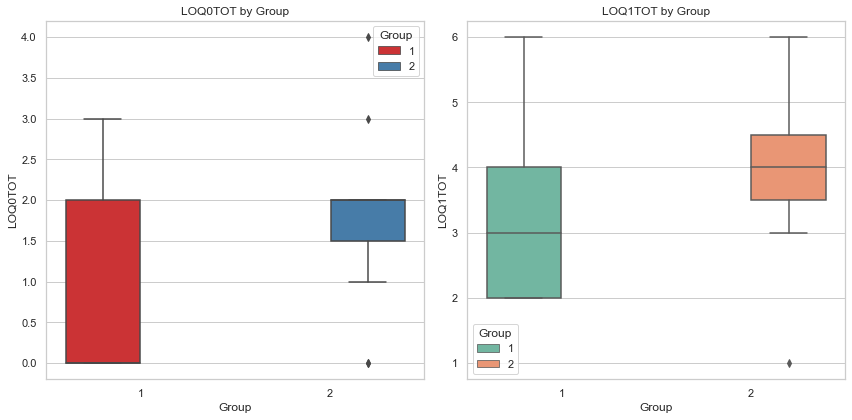

In [1]:
import pandas as pd
from scipy.stats import mannwhitneyu, shapiro
import seaborn as sns
import matplotlib.pyplot as plt

# Data setup
data = {
    "Group": [1, 2, 2, 2, 1, 2, 2, 1, 1, 1, 2, 1, 1, 2, 1, 2, 2, 1, 2, 2],
    "LOQ0TOT": [2, 0, 2, 4, 2, 2, 1, 0, 0, 2, 2, 0, 0, 2, 0, 2, 3, 3, 2, 0],
    "LOQ1TOT": [5, 3, 1, 6, 2, 4, 3, 3, 2, 6, 4, 2, 3, 4, 4, 4, 4, 3, 6, 5]
}
df = pd.DataFrame(data)

# Normality Test for LOQ0TOT and LOQ1TOT
print("Normality Test for LOQ0TOT:", shapiro(df['LOQ0TOT']))
print("Normality Test for LOQ1TOT:", shapiro(df['LOQ1TOT']))

# Mann-Whitney U Test to compare LOQ0TOT and LOQ1TOT irrespective of the group
stat, p = mannwhitneyu(df['LOQ0TOT'], df['LOQ1TOT'], alternative='two-sided')
print("P-value for comparing LOQ0TOT and LOQ1TOT:", p)
print("Test Statistic for comparing LOQ0TOT and LOQ1TOT:", stat)

# Mann-Whitney U Test for LOQ1TOT across groups
group1 = df[df['Group'] == 1]
group2 = df[df['Group'] == 2]
stat_group, p_LOQ1TOT_groups = mannwhitneyu(group1['LOQ1TOT'], group2['LOQ1TOT'], alternative='two-sided')
print("P-value for LOQ1TOT across groups:", p_LOQ1TOT_groups)
print("Test Statistic for LOQ1TOT across groups:", stat_group)

# Plotting
sns.set(style="whitegrid")
fig, axs = plt.subplots(1, 2, figsize=(12, 6))

# Plot for LOQ0TOT
sns.boxplot(x='Group', y='LOQ0TOT', data=df, hue='Group', palette="Set1", ax=axs[0])
axs[0].set_title('LOQ0TOT by Group')
axs[0].legend(title='Group')

# Plot for LOQ1TOT
sns.boxplot(x='Group', y='LOQ1TOT', data=df, hue='Group', palette="Set2", ax=axs[1])
axs[1].set_title('LOQ1TOT by Group')
axs[1].legend(title='Group')

plt.tight_layout()
plt.show()


In [2]:
import pandas as pd
from scipy.stats import mannwhitneyu

# Creating a DataFrame from the provided data
data = {
    "Group": [1, 2, 2, 2, 1, 2, 2, 1, 1, 1, 2, 1, 1, 2, 1, 2, 1, 2, 2],
    "Q1LOQ1": [0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1],
    "Q2LOQ1": [1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0],
    "Q3LOQ1": [1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
    "Q4LOQ1": [1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
    "Q5LOQ1": [1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1],
    "Q6LOQ1": [1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1]
}

df = pd.DataFrame(data)

# Filter data for Group 1 and Group 2
group1 = df[df['Group'] == 1]
group2 = df[df['Group'] == 2]

# Run Mann-Whitney U Test for each question
questions = ['Q1LOQ1', 'Q2LOQ1', 'Q3LOQ1', 'Q4LOQ1', 'Q5LOQ1', 'Q6LOQ1']
results = {}

for question in questions:
    stat, p_value = mannwhitneyu(group1[question], group2[question], alternative='two-sided')
    results[question] = (stat, p_value)

# Print results
for question, result in results.items():
    print(f"{question}: Test Statistic = {result[0]}, P-value = {result[1]}")


Q1LOQ1: Test Statistic = 28.0, P-value = 0.11566944312759772
Q2LOQ1: Test Statistic = 42.0, P-value = 0.8072501679320072
Q3LOQ1: Test Statistic = 49.5, P-value = 0.3990751965482372
Q4LOQ1: Test Statistic = 40.0, P-value = 0.34278171114791145
Q5LOQ1: Test Statistic = 37.0, P-value = 0.44752091013046924
Q6LOQ1: Test Statistic = 43.5, P-value = 0.9193330052953381


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu

# Define data for each group separately
data_group1 = {
    "Group": [1]*9,
    "Mentally_Demanding": [3, 5, 5, 3, 6, 4, 3, 5, 2],
    "Physically_Demanding": [3, 2, 5, 3, 4, 2, 2, 2, 2],
    "Pace": [6, 3, 2, 4, 1, 1, 2, 5, 3],
    "Work_Effort": [7, 5, 5, 4, 6, 4, 3, 3, 2],
    "Emotional_Stress": [6, 6, 4, 2, 6, 1, 3, 2, 2]
}

data_group2 = {
    "Group": [2]*10,
    "Mentally_Demanding": [2, 6, 2, 1, 2, 2, 3, 1, 2, 5],
    "Physically_Demanding": [2, 5, 1, 2, 2, 2, 3, 1, 4, 6],
    "Pace": [1, 5, 3, 2, 4, 4, 4, 1, 2, 2],
    "Work_Effort": [5, 2, 1, 2, 2, 2, 4, 1, 2, 5],
    "Emotional_Stress": [5, 4, 1, 2, 1, 1, 1, 1, 2, 5]
}

df1 = pd.DataFrame(data_group1)
df2 = pd.DataFrame(data_group2)

# Combine both groups into a single DataFrame
df = pd.concat([df1, df2], ignore_index=True)

# Separate data for Group 1 and Group 2 again for analysis
group1 = df[df['Group'] == 1]
group2 = df[df['Group'] == 2]

# List of categories
categories = ["Mentally_Demanding", "Physically_Demanding", "Pace", "Work_Effort", "Emotional_Stress"]

# Applying Mann-Whitney U Test for each category
results = {}
for category in categories:
    stat, p_value = mannwhitneyu(group1[category], group2[category], alternative='two-sided')
    results[category] = (stat, p_value)

# Output results
for category, result in results.items():
    print(f"{category}: Test Statistic = {result[0]}, P-value = {result[1]}")

# Plotting
plt.figure(figsize=(12, 8))
for i, category in enumerate(categories, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(x='Group', y=category, data=df)
    plt.title(category)

plt.tight_layout()
plt.show()

mental_median_g1 = group1['Mentally_Demanding'].median()
mental_median_g2 = group2['Mentally_Demanding'].median()
effort_median_g1 = group1['Work_Effort'].median()
effort_median_g2 = group2['Work_Effort'].median()

print(f"Group 1 - Median Mentally Demanding: {mental_median_g1}, Median Work Effort: {effort_median_g1}")
print(f"Group 2 - Median Mentally Demanding: {mental_median_g2}, Median Work Effort: {effort_median_g2}")

Mann-Whitney U Test Results:
Test Statistic: 40.5
P-value: 0.7435369466885651

Descriptive Statistics:
Group 1 - Mean SUS Score: 71.39, Std Dev: 14.95
Group 2 - Mean SUS Score: 72.75, Std Dev: 17.66


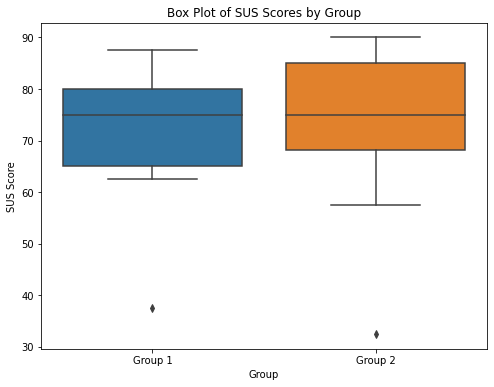

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu

# Define SUS scores separately for each group to avoid any issues
data_group1 = {
    "Group": "Group 1",
    "SUS_Score": [37.5, 80, 75, 65, 62.5, 82.5, 77.5, 75, 87.5]
}

data_group2 = {
    "Group": "Group 2",
    "SUS_Score": [32.5, 77.5, 72.5, 67.5, 85, 70, 90, 85, 90, 57.5]
}

# Convert to DataFrame
df1 = pd.DataFrame(data_group1)
df2 = pd.DataFrame(data_group2)

# Combine into a single DataFrame
df = pd.concat([df1, df2], ignore_index=True)

# Mann-Whitney U Test
stat, p_value = mannwhitneyu(df1['SUS_Score'], df2['SUS_Score'], alternative='two-sided')

# Print the results of the test
print("Mann-Whitney U Test Results:")
print(f"Test Statistic: {stat}")
print(f"P-value: {p_value}")

# Calculate descriptive statistics
desc_stats_group1 = df1['SUS_Score'].agg(['mean', 'std'])
desc_stats_group2 = df2['SUS_Score'].agg(['mean', 'std'])

# Print descriptive statistics
print("\nDescriptive Statistics:")
print("Group 1 - Mean SUS Score: {:.2f}, Std Dev: {:.2f}".format(desc_stats_group1['mean'], desc_stats_group1['std']))
print("Group 2 - Mean SUS Score: {:.2f}, Std Dev: {:.2f}".format(desc_stats_group2['mean'], desc_stats_group2['std']))

# Plotting
plt.figure(figsize=(8, 6))
sns.boxplot(x='Group', y='SUS_Score', data=df)
plt.title('Box Plot of SUS Scores by Group')
plt.xlabel('Group')
plt.ylabel('SUS Score')
plt.show()


Frequent_Use: Statistic = 54.0, P-value = 0.7698865844560637
Unnecessarily_Complex: Statistic = 33.5, P-value = 0.2008293312123639
Easy_to_Use: Statistic = 56.5, P-value = 0.5924772644915217
Technical_Support_Needed: Statistic = 50.0, P-value = 0.9677173392025162
Well_Integrated_Functions: Statistic = 46.5, P-value = 0.7863507532043057
Much_Inconsistency: Statistic = 59.0, P-value = 0.48419777880294324
Quick_to_Learn: Statistic = 42.0, P-value = 0.4820510276016917
Cumbersome: Statistic = 62.0, P-value = 0.3616843360727334
Felt_Confident: Statistic = 26.5, P-value = 0.04819133240822251
Needed_to_Learn: Statistic = 76.0, P-value = 0.043112719178807817


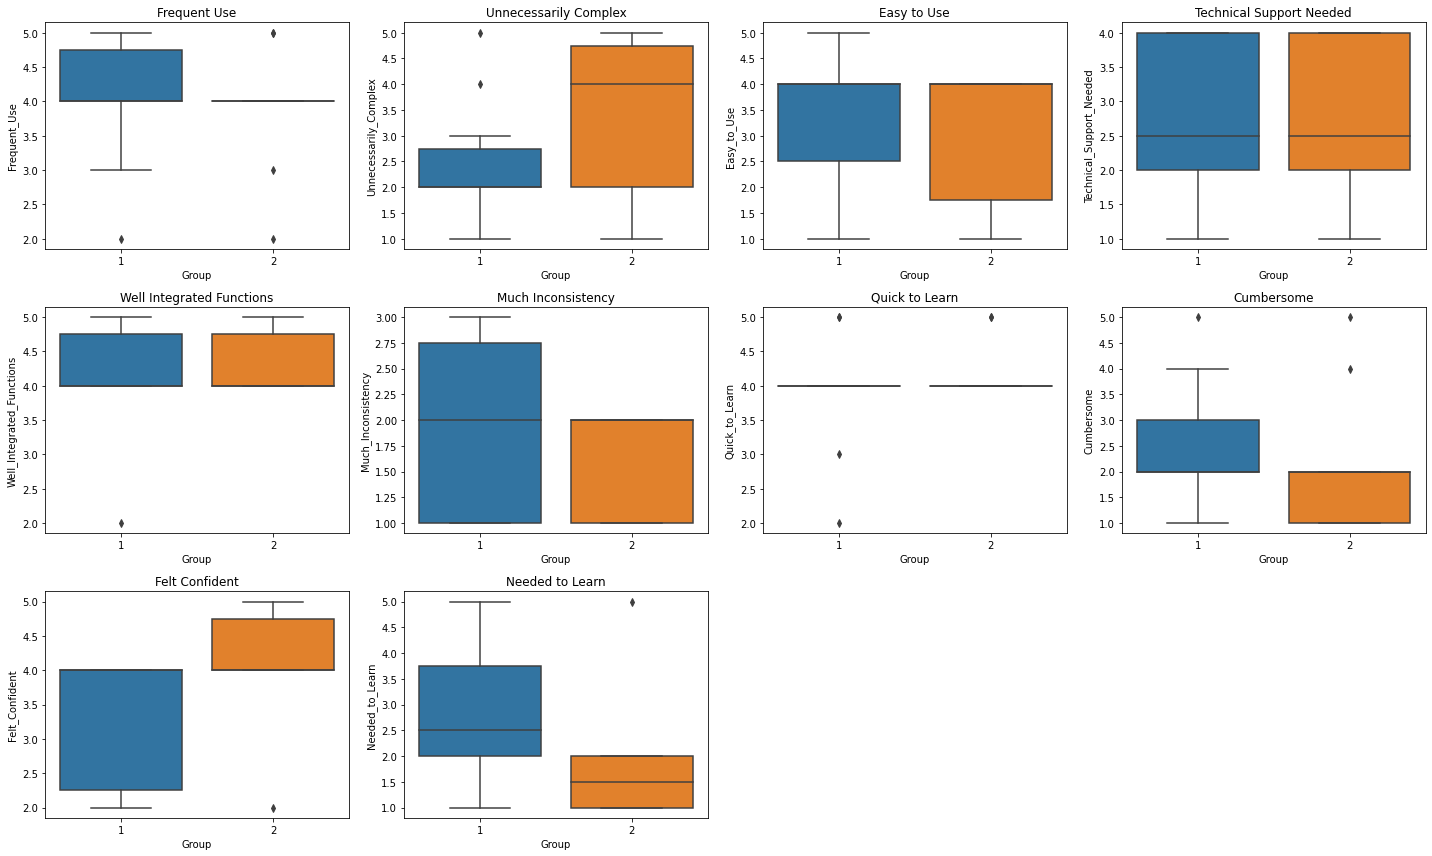

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu

# Define the data for Group 1
data_group1 = {
    "Group": [1] * 10,
    "Frequent_Use": [4, 2, 4, 3, 4, 5, 5, 4, 4, 5],
    "Unnecessarily_Complex": [4, 5, 2, 2, 2, 2, 2, 2, 3, 1],
    "Easy_to_Use": [2, 1, 4, 4, 4, 4, 4, 4, 5, 2],
    "Technical_Support_Needed": [4, 4, 2, 2, 1, 4, 2, 3, 2, 4],
    "Well_Integrated_Functions": [2, 4, 5, 4, 4, 5, 5, 4, 4, 4],
    "Much_Inconsistency": [2, 1, 2, 3, 1, 1, 1, 2, 3, 3],
    "Quick_to_Learn": [2, 4, 5, 4, 4, 4, 4, 4, 3, 5],
    "Cumbersome": [4, 5, 3, 2, 2, 2, 1, 1, 3, 2],
    "Felt_Confident": [2, 2, 4, 4, 4, 2, 4, 4, 4, 3],
    "Needed_to_Learn": [3, 5, 2, 1, 2, 4, 2, 2, 3, 4]
}

# Define the data for Group 2
data_group2 = {
    "Group": [2] * 10,
    "Frequent_Use": [2, 4, 5, 4, 4, 4, 4, 4, 3, 5],
    "Unnecessarily_Complex": [5, 2, 4, 2, 5, 1, 4, 5, 2, 4],
    "Easy_to_Use": [1, 4, 4, 4, 4, 1, 4, 1, 4, 4],
    "Technical_Support_Needed": [4, 2, 4, 3, 2, 2, 4, 2, 4, 1],
    "Well_Integrated_Functions": [4, 5, 4, 5, 4, 4, 4, 5, 4, 4],
    "Much_Inconsistency": [1, 2, 2, 1, 2, 1, 2, 2, 1, 2],
    "Quick_to_Learn": [4, 4, 4, 4, 5, 4, 4, 4, 4, 5],
    "Cumbersome": [5, 2, 1, 1, 2, 1, 1, 2, 2, 4],
    "Felt_Confident": [2, 4, 4, 4, 5, 4, 4, 4, 5, 5],
    "Needed_to_Learn": [5, 2, 1, 1, 2, 2, 1, 1, 2, 1]
}

# Convert dictionaries to DataFrames
df_group1 = pd.DataFrame(data_group1)
df_group2 = pd.DataFrame(data_group2)

# Results dictionary
results = {}

# Mann-Whitney U Test for each SUS component
for column in df_group1.columns[1:]:  # skipping 'Group' column
    stat, p_value = mannwhitneyu(df_group1[column], df_group2[column], alternative='two-sided')
    results[column] = (stat, p_value)

# Printing results
for test, result in results.items():
    print(f"{test}: Statistic = {result[0]}, P-value = {result[1]}")

# Plotting
plt.figure(figsize=(20, 12))
for i, column in enumerate(df_group1.columns[1:], 1):  # skip 'Group'
    plt.subplot(3, 4, i)  # Adjust subplot layout based on the number of variables
    sns.boxplot(x='Group', y=column, data=pd.concat([df_group1, df_group2]))
    plt.title(column.replace('_', ' '))

plt.tight_layout()
plt.show()


In [11]:
# Compute descriptive statistics for Group 1
desc_stats_group1 = df_group1.drop(columns='Group').describe()

# Compute descriptive statistics for Group 2
desc_stats_group2 = df_group2.drop(columns='Group').describe()

# Print descriptive statistics
print("Descriptive Statistics for Group 1:")
print(desc_stats_group1)

print("\nDescriptive Statistics for Group 2:")
print(desc_stats_group2)


Descriptive Statistics for Group 1:
       Frequent_Use  Unnecessarily_Complex  Easy_to_Use  \
count     10.000000              10.000000    10.000000   
mean       4.000000               2.500000     3.400000   
std        0.942809               1.178511     1.264911   
min        2.000000               1.000000     1.000000   
25%        4.000000               2.000000     2.500000   
50%        4.000000               2.000000     4.000000   
75%        4.750000               2.750000     4.000000   
max        5.000000               5.000000     5.000000   

       Technical_Support_Needed  Well_Integrated_Functions  \
count                 10.000000                  10.000000   
mean                   2.800000                   4.100000   
std                    1.135292                   0.875595   
min                    1.000000                   2.000000   
25%                    2.000000                   4.000000   
50%                    2.500000                   4.000000  

Comfort: Statistic = 40.0, P-value = 0.7130624975592306
Cumbersome: Statistic = 57.5, P-value = 0.3261236604591369


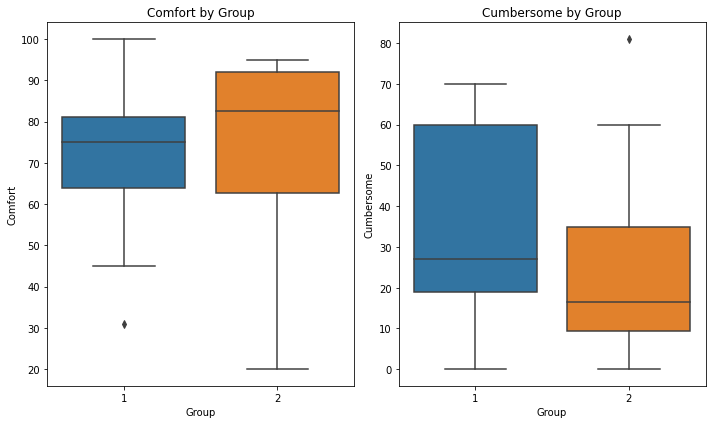

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu

# Define the data
data = {
    "Comfort": [81, 20, 29, 95, 31, 86, 83, 64, 92, 100, 60, 75, 73, 71, 75, 82, 45, 94, 94],
    "Cumbersome": [27, 81, 40, 0, 63, 18, 0, 70, 19, 0, 20, 29, 23, 15, 9, 60, 60, 14, 8],
    "Group": [1, 2, 2, 2, 1, 2, 2, 1, 1, 1, 2, 1, 1, 2, 1, 2, 1, 2, 2]
}

df = pd.DataFrame(data)

# Results dictionary
results = {}

# Mann-Whitney U Test for each variable
for column in ['Comfort', 'Cumbersome']:
    stat, p_value = mannwhitneyu(df[df['Group'] == 1][column], df[df['Group'] == 2][column], alternative='two-sided')
    results[column] = (stat, p_value)

# Printing results
for test, result in results.items():
    print(f"{test}: Statistic = {result[0]}, P-value = {result[1]}")

# Plotting box plots
plt.figure(figsize=(10, 6))
for i, column in enumerate(['Comfort', 'Cumbersome'], 1):
    plt.subplot(1, 2, i)
    sns.boxplot(x='Group', y=column, data=df)
    plt.title(f'{column} by Group')

plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Define the data
data = {
    "Operations Manual": [3, 4, 1, 1, 2, 2, 3, 3, 2, 2, 1, 2, 4, 1, 3, 1, 4, 1, 2],
    "Video of Task": [4, 3, 1, 1, 1, 1, 1, 3, 1, 1, 1, 1, 2, 2, 4, 1, 3, 1, 3],
    "Animations": [2, 2, 2, 3, 4, 4, 3, 1, 2, 3, 2, 2, 4, 1, 2, 3, 2, 2, 2],
    "Text Instructions": [1, 1, 4, 2, 3, 3, 4, 4, 4, 4, 3, 4, 1, 3, 1, 4, 1, 4, 4],
    "LOQ1Group": [1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1]
}

df = pd.DataFrame(data)

# Calculate the average rank for each learning method within each group
avg_ranks = df.groupby('LOQ1Group').mean()

# Plot horizontal bar plots for each group
plt.figure(figsize=(10, 6))
for group in avg_ranks.index:
    plt.barh(avg_ranks.columns, avg_ranks.loc[group], label=f'Group {group}')

plt.xlabel('Average Rank')
plt.ylabel('Learning Method')
plt.title('Preferred Order of Learning Methods by Group')
plt.legend()
plt.gca().invert_yaxis()  # Invert y-axis to show the highest-ranked method at the top
plt.show()


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Define the data
data = {
    "Operations Manual": [3, 4, 1, 1, 2, 2, 3, 3, 2, 2, 1, 2, 4, 1, 3, 1, 4, 1, 2],
    "Video of Task": [4, 3, 1, 1, 1, 1, 1, 3, 1, 1, 1, 1, 2, 2, 4, 1, 3, 1, 3],
    "Animations": [2, 2, 2, 3, 4, 4, 3, 1, 2, 3, 2, 2, 4, 1, 2, 3, 2, 2, 2],
    "Text Instructions": [1, 1, 4, 2, 3, 3, 4, 4, 4, 4, 3, 4, 1, 3, 1, 4, 1, 4, 4],
    "LOQ1Group": [1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1]
}

df = pd.DataFrame(data)

# Create a heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(df.groupby('LOQ1Group').mean(), annot=True, cmap='viridis', fmt=".1f")
plt.title('Rankings of Learning Methods by Group')
plt.xlabel('Learning Method')
plt.ylabel('Group')
plt.show()

# Create a parallel coordinates plot
plt.figure(figsize=(10, 6))
pd.plotting.parallel_coordinates(df, 'LOQ1Group', colormap='viridis')
plt.title('Rankings of Learning Methods by Participant')
plt.xlabel('Learning Method')
plt.ylabel('Rank')
plt.xticks(rotation=45)
plt.legend(title='Group', labels=['Group 1', 'Group 2'])
plt.show()

mode_ranks = df.groupby('LOQ1Group').apply(lambda x: x.mode(axis=0).iloc[0])

# Calculate mode ranking for each learning method by group
mode_ranks = df.groupby('LOQ1Group').apply(lambda x: x.mode(axis=0).iloc[0])

# Sort learning methods based on their mode ranks to determine ideal ranking
ideal_ranking_group1 = mode_ranks.loc[1].sort_values()
ideal_ranking_group2 = mode_ranks.loc[2].sort_values()

# Plot bar plots for ideal rankings
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
ideal_ranking_group1.plot(kind='bar', color='skyblue')
plt.title('Ideal Ranking for Group 1')
plt.xlabel('Learning Method')
plt.ylabel('Rank')
plt.ylim(0, 4)
plt.xticks(range(len(ideal_ranking_group1)), ideal_ranking_group1.index, rotation=45)

plt.subplot(1, 2, 2)
ideal_ranking_group2.plot(kind='bar', color='lightgreen')
plt.title('Ideal Ranking for Group 2')
plt.xlabel('Learning Method')
plt.ylabel('Rank')
plt.ylim(0, 4)
plt.xticks(range(len(ideal_ranking_group2)), ideal_ranking_group2.index, rotation=45)

plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Define the data
data = {
    "Operations Manual": [3, 4, 1, 1, 2, 2, 3, 3, 2, 2, 1, 2, 4, 1, 3, 1, 4, 1, 2],
    "Video of Task": [4, 3, 1, 1, 1, 1, 1, 3, 1, 1, 1, 1, 2, 2, 4, 1, 3, 1, 3],
    "Animations": [2, 2, 2, 3, 4, 4, 3, 1, 2, 3, 2, 2, 4, 1, 2, 3, 2, 2, 2],
    "Text Instructions": [1, 1, 4, 2, 3, 3, 4, 4, 4, 4, 3, 4, 1, 3, 1, 4, 1, 4, 4],
    "LOQ1Group": [1, 2, 2, 2, 1, 2, 2, 1, 1, 1, 2, 1, 1, 2, 1, 2, 1, 2, 2]
    
}

df = pd.DataFrame(data)

# Calculate mode ranking for each learning method by group
mode_ranks = df.groupby('LOQ1Group').apply(lambda x: x.mode(axis=0).iloc[0])

# Sort learning methods based on their mode ranks to determine ideal ranking
ideal_ranking_group1 = mode_ranks.loc[1].sort_values()
ideal_ranks_group1 = ideal_ranking_group1.drop('LOQ1Group').values

ideal_ranking_group2 = mode_ranks.loc[2].sort_values()
ideal_ranks_group2 = ideal_ranking_group2.drop('LOQ1Group').values

# Plot bar plots for ideal rankings
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.bar(range(len(ideal_ranks_group1)), ideal_ranks_group1, color='skyblue')
plt.title('Ideal Ranking for Group 1')
plt.xlabel('Learning Method')
plt.ylabel('Rank')
plt.ylim(0, 4)
plt.xticks(range(len(ideal_ranks_group1)), df.drop('LOQ1Group', axis=1).columns, rotation=45)
plt.gca().yaxis.grid(True)  # Add horizontal gridlines

plt.subplot(1, 2, 2)
plt.bar(range(len(ideal_ranks_group2)), ideal_ranks_group2, color='lightgreen')
plt.title('Ideal Ranking for Group 2')
plt.xlabel('Learning Method')
plt.ylabel('Rank')
plt.ylim(0, 4)
plt.xticks(range(len(ideal_ranks_group2)), df.drop('LOQ1Group', axis=1).columns, rotation=45)
plt.gca().yaxis.grid(True)  # Add horizontal gridlines

plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Data setup
data = {
    "Operations Manual": [3, 4, 1, 1, 2, 2, 3, 3, 2, 2, 1, 2, 4, 1, 3, 1, 4, 1, 2],
    "Video of Task": [4, 3, 1, 1, 1, 1, 1, 3, 1, 1, 1, 1, 2, 2, 4, 1, 3, 1, 3],
    "Animations": [2, 2, 2, 3, 4, 4, 3, 1, 2, 3, 2, 2, 4, 1, 2, 3, 2, 2, 2],
    "Text Instructions": [1, 1, 4, 2, 3, 3, 4, 4, 4, 4, 3, 4, 1, 3, 1, 4, 1, 4, 4],
    "Group": [1, 2, 2, 2, 1, 2, 2, 1, 1, 1, 2, 1, 1, 2, 1, 2, 1, 2, 2]
}

# Convert data into DataFrame
df = pd.DataFrame(data)

# Group by 'Group' and calculate mean for each material type
group_preferences = df.groupby('Group').mean()

# Plotting
ax = group_preferences.T.plot(kind='bar')
ax.set_title('Average Material Preference Ranking by Group')
ax.set_xlabel('Material Type')
ax.set_ylabel('Average Rank')
ax.invert_yaxis()  # Lower ranks are better, so invert the axis
ax.legend(title='Group', labels=['Group 1', 'Group 2'])
plt.xticks(rotation=45)
plt.show()


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Data setup
data = {
    "Operations Manual": [3, 4, 1, 1, 2, 2, 3, 3, 2, 2, 1, 2, 4, 1, 3, 1, 4, 1, 2],
    "Video of Task": [4, 3, 1, 1, 1, 1, 1, 3, 1, 1, 1, 1, 2, 2, 4, 1, 3, 1, 3],
    "Animations": [2, 2, 2, 3, 4, 4, 3, 1, 2, 3, 2, 2, 4, 1, 2, 3, 2, 2, 2],
    "Text Instructions": [1, 1, 4, 2, 3, 3, 4, 4, 4, 4, 3, 4, 1, 3, 1, 4, 1, 4, 4],
    "Group": [1, 2, 2, 2, 1, 2, 2, 1, 1, 1, 2, 1, 1, 2, 1, 2, 1, 2, 2]
}

# Convert data into DataFrame
df = pd.DataFrame(data)

# Separate the data into Group 1 and Group 2
group1_data = df[df['Group'] == 1].drop('Group', axis=1)
group2_data = df[df['Group'] == 2].drop('Group', axis=1)

# Calculate cumulative ranks
group1_ranks = group1_data.mean().sort_values(ascending=False)
group2_ranks = group2_data.mean().sort_values(ascending=False)

# Plot for Group 1
plt.plot(group1_ranks.values, marker='o', color='red', label='Group 1')

# Plot for Group 2
plt.plot(group2_ranks.values, marker='o', color='blue', label='Group 2')

plt.title('Learning Tool Preference Comparison')
plt.xlabel('Learning Tool Preference')
plt.ylabel('Cumulative Rank')
plt.xticks(range(len(group1_ranks.index)), group1_ranks.index, rotation=45)
plt.yticks(range(1, 5))  # Set y-ticks to show scale from 1 to 4
plt.ylim(1, 4)  # Set the limits of y-axis to be from 1 to 4
plt.legend()
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

# Save the plot to a file
file_name = 'PrefOrd.png'
plt.savefig(file_name)

plt.show()


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np  # Import numpy for handling array operations

# Data setup
data = {
    "Operations Manual": [3, 4, 1, 1, 2, 2, 3, 3, 2, 2, 1, 2, 4, 1, 3, 1, 4, 1, 2],
    "Video of Task": [4, 3, 1, 1, 1, 1, 1, 3, 1, 1, 1, 1, 2, 2, 4, 1, 3, 1, 3],
    "Animations": [2, 2, 2, 3, 4, 4, 3, 1, 2, 3, 2, 2, 4, 1, 2, 3, 2, 2, 2],
    "Text Instructions": [1, 1, 4, 2, 3, 3, 4, 4, 4, 4, 3, 4, 1, 3, 1, 4, 1, 4, 4],
    "Group": [1, 2, 2, 2, 1, 2, 2, 1, 1, 1, 2, 1, 1, 2, 1, 2, 1, 2, 2]
}

# Convert data into DataFrame
df = pd.DataFrame(data)

# Separate the data into Group 1 and Group 2
group1_data = df[df['Group'] == 1].drop('Group', axis=1)
group2_data = df[df['Group'] == 2].drop('Group', axis=1)

# Calculate cumulative ranks
group1_ranks = group1_data.mean()
group2_ranks = group2_data.mean()

# Define bar width and x locations for the groups
bar_width = 0.35
index = np.arange(len(group1_ranks))

# Create bars with specified figure size
fig, ax = plt.subplots(figsize=(12, 8))  # Larger figure size
bars1 = ax.bar(index - bar_width/2, group1_ranks.values, bar_width, label='Group 1', color='red')
bars2 = ax.bar(index + bar_width/2, group2_ranks.values, bar_width, label='Group 2', color='blue')

# Labeling and aesthetics
ax.set_xlabel('Learning Tool Preference', fontweight='bold', fontsize=16)
ax.set_ylabel('Cumulative Rank', fontweight='bold', fontsize=16)
ax.set_title('Learning Tool Preference Comparison', fontweight='bold', fontsize=16)
ax.set_xticks(index)
ax.set_xticklabels(group1_ranks.index, rotation=45)
plt.xticks(fontweight='bold', fontsize=16)
plt.yticks(fontweight='bold', fontsize=16)
ax.set_yticks(np.arange(1, 5))
ax.set_ylim(1, 4)  # Set the limits of y-axis to be from 1 to 4
ax.legend()
ax.grid(True, axis='y', linestyle='--', alpha=0.7)

# Save and show plot
plt.tight_layout()
plt.savefig('Updated_PrefOrd_Bar.png')
plt.show()


In [ ]:
import pandas as pd

# Data setup
data = {
    "Operations Manual": [3, 4, 1, 1, 2, 2, 3, 3, 2, 2, 1, 2, 4, 1, 3, 1, 4, 1, 2],
    "Video of Task": [4, 3, 1, 1, 1, 1, 1, 3, 1, 1, 1, 1, 2, 2, 4, 1, 3, 1, 3],
    "Animations": [2, 2, 2, 3, 4, 4, 3, 1, 2, 3, 2, 2, 4, 1, 2, 3, 2, 2, 2],
    "Text Instructions": [1, 1, 4, 2, 3, 3, 4, 4, 4, 4, 3, 4, 1, 3, 1, 4, 1, 4, 4],
    "Group": [1, 2, 2, 2, 1, 2, 2, 1, 1, 1, 2, 1, 1, 2, 1, 2, 1, 2, 2]
}

# Convert data into DataFrame
df = pd.DataFrame(data)

# Group by 'Group' and calculate sum for each material type
sum_preferences = df.groupby('Group').sum()

# Display the sum of rankings for each tool for Group 1 and Group 2
sum_preferences


In [ ]:
import pandas as pd
from scipy.stats import mannwhitneyu
import matplotlib.pyplot as plt

# Create a DataFrame with the given data
data = {
    'Group': [1, 2, 2, 2, 1, 2, 2, 1, 1, 1, 2, 1, 1, 2, 1, 2, 1, 2, 2],
    'VR_Time': ['26:16', '33:32', '28:01', '30:36', '20:39', '11:49', '28:57', '35:36', '25:11', '28:25', '28:50', '21:05', '30:50', '21:55', '20:46', '16:13', '12:28', '19:15', '31:17'],
    'AR_Time': ['18:01', '24:38', '17:42', '22:40', '30:09', '20:05', '18:41', '24:00', '14:14', '23:11', '20:00', '11:49', '22:41', '22:02', '7:09', '17:14', '17:12', '26:59', '14:43']
}
df = pd.DataFrame(data)

# Convert time strings to seconds
df['VR_Time'] = df['VR_Time'].apply(lambda x: int(x.split(':')[0]) * 60 + int(x.split(':')[1]))
df['AR_Time'] = df['AR_Time'].apply(lambda x: int(x.split(':')[0]) * 60 + int(x.split(':')[1]))

# Calculate mean and standard deviation for Group 1 and Group 2
statistics = df.groupby('Group').agg({'VR_Time': ['mean', 'std'], 'AR_Time': ['mean', 'std']})
statistics.columns = ['VR_Time_Mean', 'VR_Time_Std', 'AR_Time_Mean', 'AR_Time_Std']
statistics.index = ['Group 1', 'Group 2']
statistics['VR_Time_Mean'] = statistics['VR_Time_Mean'].apply(lambda x: f"{int(x//60):02d}:{int(x%60):02d}")
statistics['VR_Time_Std'] = statistics['VR_Time_Std'].apply(lambda x: f"{int(x//60):02d}:{int(x%60):02d}")
statistics['AR_Time_Mean'] = statistics['AR_Time_Mean'].apply(lambda x: f"{int(x//60):02d}:{int(x%60):02d}")
statistics['AR_Time_Std'] = statistics['AR_Time_Std'].apply(lambda x: f"{int(x//60):02d}:{int(x%60):02d}")
print(statistics)

# Perform Mann-Whitney U test
statistic_vr, pvalue_vr = mannwhitneyu(df[df['Group'] == 1]['VR_Time'], df[df['Group'] == 2]['VR_Time'])
statistic_ar, pvalue_ar = mannwhitneyu(df[df['Group'] == 1]['AR_Time'], df[df['Group'] == 2]['AR_Time'])
print(f"Mann-Whitney U test for VR Time: statistic={statistic_vr}, p-value={pvalue_vr}")
print(f"Mann-Whitney U test for AR Time: statistic={statistic_ar}, p-value={pvalue_ar}")

# Create box plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
df.boxplot(column='VR_Time', by='Group', ax=ax1, boxprops=dict(color='blue'), medianprops=dict(color='black'))
df.boxplot(column='AR_Time', by='Group', ax=ax2, boxprops=dict(color='blue'), medianprops=dict(color='black'))

# Change box colors for Group 1
for patch, color in zip(ax1.artists, ['red', 'blue']):
    patch.set_facecolor(color)
for patch, color in zip(ax2.artists, ['red', 'blue']):
    patch.set_facecolor(color)

ax1.set_title('VR Time')
ax2.set_title('AR Time')
plt.suptitle('')
plt.show()


In [ ]:
import pandas as pd
from scipy.stats import mannwhitneyu
import matplotlib.pyplot as plt

# Sample data
data = {
    'Group': [1, 2, 2, 2, 1, 2, 2, 1, 1, 1, 2, 1, 1, 2, 1, 2, 1, 2, 2],
    'VR_Time': ['26:16', '33:32', '28:01', '30:36', '20:39', '11:49', '28:57', '35:36', '25:11', '28:25', '28:50', '21:05', '30:50', '21:55', '20:46', '16:13', '12:28', '19:15', '31:17'],
    'AR_Time': ['18:01', '24:38', '17:42', '22:40', '30:09', '20:05', '18:41', '24:00', '14:14', '23:11', '20:00', '11:49', '22:41', '22:02', '7:09', '17:14', '17:12', '26:59', '14:43']
}
df = pd.DataFrame(data)

# Convert time strings to seconds
df['VR_Time'] = df['VR_Time'].apply(lambda x: int(x.split(':')[0]) * 60 + int(x.split(':')[1]))
df['AR_Time'] = df['AR_Time'].apply(lambda x: int(x.split(':')[0]) * 60 + int(x.split(':')[1]))

# Calculate joint time for each group
df['Joint_Time'] = df['VR_Time'] + df['AR_Time']

# Calculate mean and standard deviation for Group 1 and Group 2
statistics = df.groupby('Group').agg({'VR_Time': ['mean', 'std'], 'AR_Time': ['mean', 'std'], 'Joint_Time': ['mean', 'std']})
statistics.columns = ['VR_Time_Mean', 'VR_Time_Std', 'AR_Time_Mean', 'AR_Time_Std', 'Joint_Time_Mean', 'Joint_Time_Std']
statistics.index = ['Group 1', 'Group 2']
statistics['VR_Time_Mean'] = statistics['VR_Time_Mean'].apply(lambda x: f"{int(x//60):02d}:{int(x%60):02d}")
statistics['VR_Time_Std'] = statistics['VR_Time_Std'].apply(lambda x: f"{int(x//60):02d}:{int(x%60):02d}")
statistics['AR_Time_Mean'] = statistics['AR_Time_Mean'].apply(lambda x: f"{int(x//60):02d}:{int(x%60):02d}")
statistics['AR_Time_Std'] = statistics['AR_Time_Std'].apply(lambda x: f"{int(x//60):02d}:{int(x%60):02d}")
statistics['Joint_Time_Mean'] = statistics['Joint_Time_Mean'].apply(lambda x: f"{int(x//60):02d}:{int(x%60):02d}")
statistics['Joint_Time_Std'] = statistics['Joint_Time_Std'].apply(lambda x: f"{int(x//60):02d}:{int(x%60):02d}")
print(statistics)

# Perform Mann-Whitney U test for Joint Time
statistic_joint, pvalue_joint = mannwhitneyu(df[df['Group'] == 1]['Joint_Time'], df[df['Group'] == 2]['Joint_Time'])
print(f"Mann-Whitney U test for Joint Time: statistic={statistic_joint}, p-value={pvalue_joint}")


In [ ]:
# Calculate average time for AR and VR irrespective of group
average_ar_time = df['AR_Time'].mean()
average_vr_time = df['VR_Time'].mean()

# Convert average times to mm:ss format
average_ar_time_formatted = f"{int(average_ar_time // 60):02d}:{int(average_ar_time % 60):02d}"
average_vr_time_formatted = f"{int(average_vr_time // 60):02d}:{int(average_vr_time % 60):02d}"

print(f"Average AR Time: {average_ar_time_formatted}")
print(f"Average VR Time: {average_vr_time_formatted}")


In [ ]:
from scipy.stats import ttest_ind

# Separate VR and AR times for each group
vr_group1 = df[df['Group'] == 1]['VR_Time']
vr_group2 = df[df['Group'] == 2]['VR_Time']
ar_group1 = df[df['Group'] == 1]['AR_Time']
ar_group2 = df[df['Group'] == 2]['AR_Time']

# Perform t-test for VR and AR times between the two groups
t_statistic_vr, p_value_vr = ttest_ind(vr_group1, vr_group2)
t_statistic_ar, p_value_ar = ttest_ind(ar_group1, ar_group2)

print(f"T-test for VR Time: t-statistic={t_statistic_vr}, p-value={p_value_vr}")
print(f"T-test for AR Time: t-statistic={t_statistic_ar}, p-value={p_value_ar}")


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

# Define a function to format seconds to mm:ss format
def format_time(x, pos):
    minutes = int(x // 60)
    seconds = int(x % 60)
    return f"{minutes:02d}:{seconds:02d}"

# Define a palette for the groups
group_palette = {1: 'red', 2: 'blue'}

# Find the maximum time to set the y-axis limit
max_time = max(df['AR_Time'].max(), df['VR_Time'].max())
min_time = min(df['AR_Time'].min(), df['VR_Time'].min())

# Plotting
plt.figure(figsize=(16, 8))

# AR Time boxplot
plt.subplot(1, 2, 1)
sns.boxplot(x='Group', y='AR_Time', data=df, palette=group_palette)
plt.ylim(min_time - 60, max_time + 60)  # Add some padding to the top of the y-axis

plt.gca().yaxis.set_major_formatter(FuncFormatter(format_time))
plt.title('AR Time by Group', fontweight='bold', fontsize=16)
plt.ylabel('Time (mm:ss)', fontweight='bold', fontsize=16)
plt.xticks(fontweight='bold', fontsize=16)
plt.yticks(fontweight='bold', fontsize=16)
plt.xlabel('Group', fontweight='bold', fontsize=16)

# VR Time boxplot
plt.subplot(1, 2, 2)
sns.boxplot(x='Group', y='VR_Time', data=df, palette=group_palette)
plt.ylim(min_time-60, max_time + 60)  # Add some padding to the top of the y-axis
plt.gca().yaxis.set_major_formatter(FuncFormatter(format_time))
plt.title('VR Time by Group', fontweight='bold', fontsize=16)
plt.xticks(fontweight='bold', fontsize=16)
plt.yticks(fontweight='bold', fontsize=16)
plt.ylabel('Time (mm:ss)', fontweight='bold', fontsize=16)# Remove y-axis labels
plt.xlabel('Group', fontweight='bold', fontsize=16)
file_name = 'UPD_TimeG1.png'
plt.savefig(file_name)
plt.tight_layout()
plt.show()



In [ ]:
# Calculate average time for AR and VR irrespective of group
average_ar_seconds = df['AR_Time'].mean()
average_vr_seconds = df['VR_Time'].mean()

# Convert average times to mm:ss format
average_ar_time = f"{int(average_ar_seconds // 60):02d}:{int(average_ar_seconds % 60):02d}"
average_vr_time = f"{int(average_vr_seconds // 60):02d}:{int(average_vr_seconds % 60):02d}"

print(f"Average AR Time: {average_ar_time}")
print(f"Average VR Time: {average_vr_time}")


In [13]:
from scipy.stats import mannwhitneyu
import pandas as pd

# Define the data
data = {
    "Confidence": [5, 4, 3, 3, 4, 4, 5, 4, 3, 4, 4, 3, 4, 5, 2, 5, 5, 5, 3],
    "Effective_TaskTODO": [2, 3, 4, 2, 4, 4, 5, 4, 3, 4, 4, 4, 4, 4, 4, 5, 4, 5, 4],
    "LOQ1Group": [1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1]
}

df = pd.DataFrame(data)

# Separate data for Group 1 and Group 2
group1_data = df[df['LOQ1Group'] == 1]
group2_data = df[df['LOQ1Group'] == 2]

# Perform Mann-Whitney U test
confidence_statistic, confidence_p_value = mannwhitneyu(group1_data['Confidence'], group2_data['Confidence'])
skills_statistic, skills_p_value = mannwhitneyu(group1_data['Effective_TaskTODO'], group2_data['Effective_TaskTODO'])

# Interpret results
print("Mann-Whitney U test results:")
print("Confidence: Statistic =", confidence_statistic, ", P-value =", confidence_p_value)
print("Skills Enhancement: Statistic =", skills_statistic, ", P-value =", skills_p_value)


Mann-Whitney U test results:
Confidence: Statistic = 37.5 , P-value = 0.2737251389520754
Skills Enhancement: Statistic = 41.5 , P-value = 0.38820223739066556


In [ ]:
import pandas as pd

data = {
    "Group": [1, 2, 2, 2, 1, 2, 2, 1, 1, 1, 2, 1, 1, 2, 1, 2, 1, 2, 2],
    "LOQ0TOT": [2, 0, 2, 4, 2, 2, 1, 0, 0, 2, 2, 0, 0, 2, 0, 2, 3, 2, 0],
    "LOQ1TOT": [5, 3, 1, 6, 2, 4, 3, 3, 2, 6, 4, 2, 3, 4, 4, 4, 3, 6, 5],
    "LOQ2TOT": [4, 5, 3, 6, 3, 5, 4, 3, 2, 5, 5, 4, 4, 4, 5, 4, 3, 6, 3],
    "LOQ3TOT": [4, 5, 2, 5, 2, 6, 4, 4, 2, 5, 5, 3, 4, 3, 5, 5, 3, 5, 3],
    "TASKTOT": [4, 1, 4, 5, 2, 6, 2, 3, 5, 5, 1, 6, 5, 4, 6, 5, 3, 5, 4]
}

df = pd.DataFrame(data)

avg_count_loq2 = df.groupby('Group')['LOQ2TOT'].mean()
avg_count_loq3 = df.groupby('Group')['LOQ3TOT'].mean()

print("Average count for LOQ2 dependent on group:")
print(avg_count_loq2)

print("\nAverage count for LOQ3 dependent on group:")
print(avg_count_loq3)


In [ ]:
avg_count_tasktot = df.groupby('Group')['TASKTOT'].mean()

print("Average count for TASKTOT dependent on group:")
print(avg_count_tasktot)


In [ ]:
##RQ2

In [ ]:
import pandas as pd
from scipy.stats import mannwhitneyu, shapiro
import seaborn as sns
import matplotlib.pyplot as plt

# Data setup
data = {
    "Group": [1, 2, 2, 2, 1, 2, 2, 1, 1, 1, 2, 1, 1, 2, 1, 2, 1, 2, 2],
    "LOQ0TOT": [2, 0, 2, 4, 2, 2, 1, 0, 0, 2, 2, 0, 0, 2, 0, 2, 3, 2, 0],
    "LOQ1TOT": [5, 3, 1, 6, 2, 4, 3, 3, 2, 6, 4, 2, 3, 4, 4, 4, 3, 6, 5],
    "LOQ2TOT": [4, 5, 3, 6, 3, 5, 4, 3, 2, 5, 5, 4, 4, 4, 5, 4, 3, 6, 3],
    "LOQ3TOT": [4, 5, 2, 5, 2, 6, 4, 4, 2, 5, 5, 3, 4, 3, 5, 5, 3, 5, 3],
    "TASKTOT": [4, 1, 4, 5, 2, 6, 2, 3, 5, 5, 1, 6, 5, 4, 6, 5, 3, 5, 4]
}
df = pd.DataFrame(data)

# Mann-Whitney U Tests
variables = ['LOQ0TOT', 'LOQ1TOT', 'LOQ2TOT', 'LOQ3TOT', 'TASKTOT']
for i in range(len(variables)):
    for j in range(i+1, len(variables)):
        stat, p = mannwhitneyu(df[variables[i]], df[variables[j]], alternative='two-sided')
        print(f"Mann-Whitney U Test between {variables[i]} and {variables[j]}:")
        print(f"  P-value: {p}")
        print(f"  Test Statistic: {stat}")

# Box plot for all variables
plt.figure(figsize=(10, 6))
sns.boxplot(data=df.drop(columns='Group'), palette="Set1")
plt.title('Box plot of LOQ and TASK variables')
plt.ylabel('Value')
plt.xlabel('Variable')
plt.show()


In [ ]:
from scipy.stats import kruskal

# Extracting data for each LOQ level
loq0 = data['LOQ0TOT']
loq1 = data['LOQ1TOT']
loq2 = data['LOQ2TOT']
loq3 = data['LOQ3TOT']
task = data['TASKTOT']

# Performing Kruskal-Wallis test
kruskal_result = kruskal(loq0, loq1, loq2, loq3, task)
print("Kruskal-Wallis Test Result:")
print("Statistic:", kruskal_result.statistic)
print("P-value:", kruskal_result.pvalue)


In [ ]:
import pandas as pd
from scipy.stats import kruskal
import scikit_posthocs as sp
import seaborn as sns
import matplotlib.pyplot as plt

# Data
data = {
    "Group": [1, 2, 2, 2, 1, 2, 2, 1, 1, 1, 2, 1, 1, 2, 1, 2, 1, 2, 2],
    "LOQ0TOT": [2, 0, 2, 4, 2, 2, 1, 0, 0, 2, 2, 0, 0, 2, 0, 2, 3, 2, 0],
    "LOQ1TOT": [5, 3, 1, 6, 2, 4, 3, 3, 2, 6, 4, 2, 3, 4, 4, 4, 3, 6, 5],
    "LOQ2TOT": [4, 5, 3, 6, 3, 5, 4, 3, 2, 5, 5, 4, 4, 4, 5, 4, 3, 6, 3],
    "LOQ3TOT": [4, 5, 2, 5, 2, 6, 4, 4, 2, 5, 5, 3, 4, 3, 5, 5, 3, 5, 3],
    "TASKTOT": [4, 1, 4, 5, 2, 6, 2, 3, 5, 5, 1, 6, 5, 4, 6, 5, 3, 5, 4]
}

df = pd.DataFrame(data)

# Kruskal-Wallis test
kw_result = kruskal(df['LOQ0TOT'], df['LOQ1TOT'], df['LOQ2TOT'], df['LOQ3TOT'], df['TASKTOT'])

print("Kruskal-Wallis Test Result:")
print("Statistic:", kw_result.statistic)
print("P-value:", kw_result.pvalue)

# Dunn's test for pairwise comparisons
dunn_result = sp.posthoc_dunn(df, val_col='LOQ0TOT', group_col='Group', p_adjust='bonferroni')

print("\nDunn's Test Pairwise Comparisons:")
print(dunn_result)

# Box plot for each LOQ group and TASKTOT
df_melted = df.melt(id_vars='Group', var_name='LOQ', value_name='Value')

sns.boxplot(x='LOQ', y='Value', hue='Group', data=df_melted)
plt.title('Box Plot of LOQ and TASKTOT by Group')
plt.xlabel('LOQ or TASKTOT')
plt.ylabel('Value')
plt.legend(title='Group')
plt.show()


In [ ]:
from scipy.stats import mannwhitneyu

# Extract data for Group 1 and Group 2
group1_tasktot = df[df['Group'] == 1]['TASKTOT']
group2_tasktot = df[df['Group'] == 2]['TASKTOT']

# Perform Mann-Whitney U test
statistic, p_value = mannwhitneyu(group1_tasktot, group2_tasktot, alternative='two-sided')

# Display results
print("Mann-Whitney U Test Result:")
print("Statistic:", statistic)
print("P-value:", p_value)


In [ ]:
import pandas as pd
from scipy.stats import mannwhitneyu


group_info = [1, 2, 2, 2, 1, 2, 2, 1, 1, 1, 2, 1, 1, 2, 1, 2, 1, 2, 2]

loq1_data = {
    "Group": group_info,
    "Mentally_Demanding": [3, 2, 6, 2, 5, 1, 2, 5, 3, 6, 3, 4, 3, 1, 5, 2, 2, 2, 5],
    "Physically_Demanding": [3, 2, 5, 1, 2, 2, 2, 5, 3, 4, 3, 2, 2, 1, 2, 2, 2, 4, 6],
    "Pace": [6, 1, 5, 3, 3, 2, 4, 2, 4, 1, 4, 1, 2, 1, 5, 2, 3, 1, 2],
    "Work_Effort": [7, 5, 2, 1, 5, 2, 2, 5, 4, 6, 4, 4, 3, 1, 3, 2, 2, 2, 5],
    "Emotional_Stress": [6, 5, 4, 1, 6, 2, 1, 4, 2, 6, 1, 1, 3, 1, 2, 2, 2, 2, 5]
}

loq2_data = {
    "Group": group_info,
    "Mentally_Demanding": [3, 5, 5, 2, 6, 2, 6, 4, 2, 3, 4, 4, 3, 3, 5, 5, 3, 4, 6],
    "Physically_Demanding": [5, 4, 5, 3, 5, 2, 5, 6, 2, 3, 3, 3, 3, 1, 2, 5, 1, 6, 6],
    "Pace": [2, 1, 4, 1, 2, 1, 2, 2, 1, 2, 3, 1, 1, 1, 2, 1, 4, 1, 2],
    "Work_Effort": [3, 5, 3, 2, 5, 1, 5, 4, 2, 5, 5, 3, 4, 1, 6, 2, 2, 7, 7],
    "Emotional_Stress": [5, 6, 5, 2, 5, 2, 5, 2, 1, 3, 2, 1, 3, 1, 6, 4, 2, 7, 7]
}




# Convert data to DataFrames
df_loq1 = pd.DataFrame(loq1_data)
df_loq2 = pd.DataFrame(loq2_data)

# Separate data for LOQ1 and LOQ2
loq1_group1 = df_loq1[df_loq1['Group'] == 1].drop('Group', axis=1)
loq1_group2 = df_loq1[df_loq1['Group'] == 2].drop('Group', axis=1)

loq2_group1 = df_loq2[df_loq2['Group'] == 1].drop('Group', axis=1)
loq2_group2 = df_loq2[df_loq2['Group'] == 2].drop('Group', axis=1)

# Perform Mann-Whitney U test for each category within groups
results_within_groups = {}
categories = ["Mentally_Demanding", "Physically_Demanding", "Pace", "Work_Effort", "Emotional_Stress"]
for category in categories:
    stat_loq1_group1_vs_group2, p_value_loq1_group1_vs_group2 = mannwhitneyu(loq1_group1[category], loq1_group2[category], alternative='two-sided')
    stat_loq2_group1_vs_group2, p_value_loq2_group1_vs_group2 = mannwhitneyu(loq2_group1[category], loq2_group2[category], alternative='two-sided')
    results_within_groups[category] = {
        "LOQ1": (stat_loq1_group1_vs_group2, p_value_loq1_group1_vs_group2),
        "LOQ2": (stat_loq2_group1_vs_group2, p_value_loq2_group1_vs_group2)
    }

# Output results
for category, result in results_within_groups.items():
    print(f"{category}:")
    print(f"  LOQ1 - Group 1 vs Group 2: Test Statistic = {result['LOQ1'][0]}, P-value = {result['LOQ1'][1]}")
    print(f"  LOQ2 - Group 1 vs Group 2: Test Statistic = {result['LOQ2'][0]}, P-value = {result['LOQ2'][1]}")


In [ ]:
from scipy.stats import wilcoxon

# Calculate the differences for mentally demanding and work effort
mentally_demanding_diff = loq2_group1["Mentally_Demanding"] - loq1_group1["Mentally_Demanding"]
work_effort_diff = loq2_group1["Work_Effort"] - loq1_group1["Work_Effort"]

# Perform Wilcoxon signed-rank test
stat_mentally_demanding, p_value_mentally_demanding = wilcoxon(mentally_demanding_diff)
stat_work_effort, p_value_work_effort = wilcoxon(work_effort_diff)

# Output results
print("Mentally Demanding:")
print(f"  Test Statistic: {stat_mentally_demanding}, P-value: {p_value_mentally_demanding}")

print("Work Effort:")
print(f"  Test Statistic: {stat_work_effort}, P-value: {p_value_work_effort}")


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Define data
group_info = [1, 2, 2, 2, 1, 2, 2, 1, 1, 1, 2, 1, 1, 2, 1, 2, 1, 2, 2]

loq1_data = {
    "Group": group_info,
    "Mentally_Demanding": [3, 2, 6, 2, 5, 1, 2, 5, 3, 6, 3, 4, 3, 1, 5, 2, 2, 2, 5],
    "Physically_Demanding": [3, 2, 5, 1, 2, 2, 2, 5, 3, 4, 3, 2, 2, 1, 2, 2, 2, 4, 6],
    "Pace": [6, 1, 5, 3, 3, 2, 4, 2, 4, 1, 4, 1, 2, 1, 5, 2, 3, 1, 2],
    "Work_Effort": [7, 5, 2, 1, 5, 2, 2, 5, 4, 6, 4, 4, 3, 1, 3, 2, 2, 2, 5],
    "Emotional_Stress": [6, 5, 4, 1, 6, 2, 1, 4, 2, 6, 1, 1, 3, 1, 2, 2, 2, 2, 5]
}

loq2_data = {
    "Group": group_info,
    "Mentally_Demanding": [3, 5, 5, 2, 6, 2, 6, 4, 2, 3, 4, 4, 3, 3, 5, 5, 3, 4, 6],
    "Physically_Demanding": [5, 4, 5, 3, 5, 2, 5, 6, 2, 3, 3, 3, 3, 1, 2, 5, 1, 6, 6],
    "Pace": [2, 1, 4, 1, 2, 1, 2, 2, 1, 2, 3, 1, 1, 1, 2, 1, 4, 1, 2],
    "Work_Effort": [3, 5, 3, 2, 5, 1, 5, 4, 2, 5, 5, 3, 4, 1, 6, 2, 2, 7, 7],
    "Emotional_Stress": [5, 6, 5, 2, 5, 2, 5, 2, 1, 3, 2, 1, 3, 1, 6, 4, 2, 7, 7]
}

# Convert data to DataFrames
df_loq1 = pd.DataFrame(loq1_data)
df_loq2 = pd.DataFrame(loq2_data)

# Define a custom color palette for consistency
custom_palette = sns.color_palette("Set1", 2)

# Create subplots
fig, axs = plt.subplots(5, 2, figsize=(12, 24))

# Flatten the axis array for easier indexing
axs = axs.flatten()

# List of categories
categories = ["Mentally_Demanding", "Physically_Demanding", "Pace", "Work_Effort", "Emotional_Stress"]

# Custom y-axis labels for LOQ1 and LOQ2
y_labels = {'LOQ1': 'xx', 'LOQ2': 'yy'}

# Loop through categories
for i, category in enumerate(categories):
    # Plot boxplot for LOQ1
    sns.boxplot(x='Group', y=category, data=df_loq1, palette=custom_palette, ax=axs[2*i])
    axs[2*i].set_title('LOQ1')
    axs[2*i].set_xlabel('Group')
    axs[2*i].set_ylabel(y_labels['LOQ1'])  # Set y-axis label for LOQ1
    axs[2*i].set_ylim(1, 7)  # Set y-axis scale from 1 to 7

    # Plot boxplot for LOQ2
    sns.boxplot(x='Group', y=category, data=df_loq2, palette=custom_palette, ax=axs[2*i+1])
    axs[2*i+1].set_title('LOQ2')
    axs[2*i+1].set_xlabel('Group')
    axs[2*i+1].set_ylabel(y_labels['LOQ2'])  # Set y-axis label for LOQ2
    axs[2*i+1].set_ylim(1, 7)  # Set y-axis scale from 1 to 7

# Adjust layout
plt.tight_layout()

# Show plot
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Define your data
group_info = [1, 2, 2, 2, 1, 2, 2, 1, 1, 1, 2, 1, 1, 2, 1, 2, 1, 2, 2]

loq1_data = {
    "Group": group_info,
    "Mentally_Demanding": [3, 2, 6, 2, 5, 1, 2, 5, 3, 6, 3, 4, 3, 1, 5, 2, 2, 2, 5],
    "Physically_Demanding": [3, 2, 5, 1, 2, 2, 2, 5, 3, 4, 3, 2, 2, 1, 2, 2, 2, 4, 6],
    "Pace": [6, 1, 5, 3, 3, 2, 4, 2, 4, 1, 4, 1, 2, 1, 5, 2, 3, 1, 2],
    "Work_Effort": [7, 5, 2, 1, 5, 2, 2, 5, 4, 6, 4, 4, 3, 1, 3, 2, 2, 2, 5],
    "Emotional_Stress": [6, 5, 4, 1, 6, 2, 1, 4, 2, 6, 1, 1, 3, 1, 2, 2, 2, 2, 5]
}

df_loq1 = pd.DataFrame(loq1_data)

# Calculate means for each category by group
mean_data = df_loq1.groupby('Group').mean().T
mean_data.columns = ['Group 1', 'Group 2']

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
bar_width = 0.35
index = range(len(mean_data))

bars1 = plt.barh([i - bar_width/2 for i in index], mean_data['Group 1'], height=bar_width, label='Group 1', color='gray')
bars2 = plt.barh([i + bar_width/2 for i in index], mean_data['Group 2'], height=bar_width, label='Group 2', color='black')

plt.xlabel('Mean Scores')
plt.title('Group Comparison of Task Demands')
plt.yticks(index, mean_data.index)
plt.legend()

plt.tight_layout()
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
 
# Define your data
group_info = [1, 2, 2, 2, 1, 2, 2, 1, 1, 1, 2, 1, 1, 2, 1, 2, 1, 2, 2]

loq1_data = {
    "Group": group_info,
    "How mentally demanding was the task?": [3, 2, 6, 2, 5, 1, 2, 5, 3, 6, 3, 4, 3, 1, 5, 2, 2, 2, 5],
    "How physically demanding was the task?": [3, 2, 5, 1, 2, 2, 2, 5, 3, 4, 3, 2, 2, 1, 2, 2, 2, 4, 6],
    "How hurried or rushed was \n the pace of the task?": [6, 1, 5, 3, 3, 2, 4, 2, 4, 1, 4, 1, 2, 1, 5, 2, 3, 1, 2],
    "How hard did you have to work to \n accomplish your level of performance?": [7, 5, 2, 1, 5, 2, 2, 5, 4, 6, 4, 4, 3, 1, 3, 2, 2, 2, 5],
    "How insecure, discouraged, irritated,\n stressed, and annoyed were you?": [6, 5, 4, 1, 6, 2, 1, 4, 2, 6, 1, 1, 3, 1, 2, 2, 2, 2, 5]
}

loq2_data = {
    "Group": group_info,
    "How mentally demanding was the task?": [3, 5, 5, 2, 6, 2, 6, 4, 2, 3, 4, 4, 3, 3, 5, 5, 3, 4, 6],
    "How physically demanding was the task?": [5, 4, 5, 3, 5, 2, 5, 6, 2, 3, 3, 3, 3, 1, 2, 5, 1, 6, 6],
    "How hurried or rushed was \n the pace of the task?": [2, 1, 4, 1, 2, 1, 2, 2, 1, 2, 3, 1, 1, 1, 2, 1, 4, 1, 2],
    "How hard did you have to work to \n accomplish your level of performance?": [3, 5, 3, 2, 5, 1, 5, 4, 2, 5, 5, 3, 4, 1, 6, 2, 2, 7, 7],
    "How insecure, discouraged, irritated, \n stressed, and annoyed were you?": [5, 6, 5, 2, 5, 2, 5, 2, 1, 3, 2, 1, 3, 1, 6, 4, 2, 7, 7]
}

# Create DataFrames
df_loq1 = pd.DataFrame(loq1_data)
df_loq2 = pd.DataFrame(loq2_data)

# Calculate means for both datasets
means_loq1 = df_loq1.groupby('Group').mean().T
means_loq2 = df_loq2.groupby('Group').mean().T

print("Means for LOQ1:")
print(means_loq1)
print("\nMeans for LOQ2:")
print(means_loq2)
# Create the plots side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 8), sharey=True)

# Set common categories and questions
categories = means_loq1.index.tolist()

# Plotting function to avoid repetition
def plot_data(ax, data, title):
    bar_width = 0.35
    index = np.arange(len(data))
    ax.barh(index - bar_width/2, data[1], height=bar_width, color='red', label='Group 1')
    ax.barh(index + bar_width/2, data[2], height=bar_width, color='blue', label='Group 2')
    ax.set(title=title, xlabel='Mean Scores (1-7)', xlim=(1, 7))
    ax.set_yticks(index)
    ax.set_yticklabels(categories)
    ax.legend()

# Apply the plotting function to both subplots
plot_data(ax1, means_loq1, 'LOQ1 Responses')
plot_data(ax2, means_loq2, 'LOQ2 Responses')

plt.tight_layout()
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Assuming you have already calculated means_loq1 and means_loq2

# Plotting
fig, axes = plt.subplots(2, 1, figsize=(10, 12), sharex=True)  # Two subplots, vertically stacked
bar_width = 0.35
labels = means_loq1.index
x = np.arange(len(labels))

# LOQ1 Plot
axes[0].bar(x - bar_width/2, means_loq1[1], width=bar_width, label='Group 1', color='red')
axes[0].bar(x + bar_width/2, means_loq1[2], width=bar_width, label='Group 2', color='blue')
axes[0].set_title('LOQ1')
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels, rotation=45, ha='right')
axes[0].set_ylabel('Mean Scores')
axes[0].set_ylim(1, 7)
axes[0].legend()

# LOQ2 Plot
axes[1].bar(x - bar_width/2, means_loq2[1], width=bar_width, label='Group 1', color='red')
axes[1].bar(x + bar_width/2, means_loq2[2], width=bar_width, label='Group 2', color='blue')
axes[1].set_title('LOQ2')
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels, rotation=45, ha='right')
axes[1].set_xlabel('NASA TLX Questions')
axes[1].set_ylabel('Mean Scores')
axes[1].set_ylim(1, 7)
axes[1].legend()

# Adjusting spacing and saving plot
plt.tight_layout()  # Adjust spacing automatically
file_name = 'TLX_G.png'
plt.savefig(file_name)
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Calculate the differences between LOQ1 and LOQ2 for each entry
df_diff = df_loq2.drop(columns='Group') - df_loq1.drop(columns='Group')

# Set the figure size
plt.figure(figsize=(15, 6))

# Plot the overall changes
plt.subplot(1, 2, 1)
df_diff.plot(kind='bar', ax=plt.gca())
plt.title('Overall Change from LOQ1 to LOQ2')
plt.xlabel('Entry')
plt.ylabel('Change')
plt.xticks(rotation=0)
plt.legend(title='Category')

# Plot the changes sorted by group
plt.subplot(1, 2, 2)
df_diff_sorted = df_diff.groupby(df_loq1['Group']).mean()  # Calculate mean change per group
df_diff_sorted.plot(kind='bar', ax=plt.gca())
plt.title('Change from LOQ1 to LOQ2 (Sorted by Group)')
plt.xlabel('Group')
plt.ylabel('Mean Change')
plt.xticks(rotation=0)
plt.legend(title='Category')

# Show plots
plt.tight_layout()
plt.show()


In [ ]:
# Calculate the mean change from LOQ1 to LOQ2 for each group and each category
mean_change = df_diff.groupby(df_loq1['Group']).mean()

# Display the mean change
print("Mean Change from LOQ1 to LOQ2:")
print(mean_change)


In [ ]:
import pandas as pd
from scipy.stats import mannwhitneyu
import seaborn as sns
import matplotlib.pyplot as plt

# Define the data
group_info = [1, 2, 2, 2, 1, 2, 2, 1, 1, 1, 2, 1, 1, 2, 1, 2, 1, 2, 2]

loq1_data = {
    "Group": group_info,
    "Frequent_Use": [4, 2, 4, 3, 4, 5, 5, 4, 4, 5, 4, 4, 5, 5, 4, 4, 5, 4, 4],
    "Unnecessarily_Complex": [4, 5, 2, 2, 2, 2, 2, 2, 3, 1, 3, 1, 2, 2, 2, 2, 1, 2, 2],
    "Easy_to_Use": [2, 1, 4, 4, 4, 4, 4, 4, 5, 2, 4, 5, 4, 5, 3, 5, 2, 3, 2],
    "Technical_Support_Needed": [4, 4, 2, 2, 1, 4, 2, 3, 2, 4, 4, 3, 2, 1, 2, 1, 3, 1, 3],
    "Well_Integrated_Functions": [2, 4, 5, 4, 4, 5, 5, 4, 4, 4, 5, 4, 5, 4, 1, 4, 4, 4, 4],
    "Much_Inconsistency": [2, 1, 2, 3, 1, 1, 1, 2, 3, 4, 3, 2, 2, 2, 5, 4, 1, 1, 2],
    "Quick_to_Learn": [2, 4, 5, 4, 4, 4, 4, 4, 3, 5, 4, 4, 4, 5, 4, 4, 5, 4, 2],
    "Cumbersome": [4, 5, 3, 2, 2, 2, 1, 3, 3, 1, 2, 1, 2, 2, 4, 1, 2, 4, 4],
    "Felt_Confident": [2, 2, 4, 4, 4, 2, 4, 4, 4, 3, 4, 4, 3, 5, 2, 4, 5, 3, 3],
    "Needed_to_Learn": [3, 5, 1, 1, 2, 4, 2, 2, 3, 4, 1, 1, 2, 1, 2, 1, 1, 2, 2],
    "SUS_Score": [37.5, 32.5, 77.5, 72.5, 80, 67.5, 85, 75, 65, 62.5, 70, 82.5, 77.5, 90, 75, 85, 87.5, 90, 75]
}

loq2_data = {
    "Group": group_info,
    "Frequent_Use": [4, 4, 3, 4, 4, 5, 4, 5, 4, 3, 4, 4, 4, 2, 2, 3, 2, 5, 5],
    "Unnecessarily_Complex": [2, 3, 4, 1, 2, 1, 4, 1, 3, 2, 1, 2, 3, 1, 2, 4, 1, 2, 1],
    "Easy_to_Use": [4, 4, 4, 5, 4, 5, 5, 5, 2, 4, 5, 4, 4, 5, 1, 5, 4, 3, 5],
    "Technical_Support_Needed": [3, 2, 4, 4, 4, 1, 2, 1, 4, 4, 4, 4, 2, 1, 1, 4, 2, 1, 2],
    "Well_Integrated_Functions": [4, 4, 4, 4, 4, 5, 4, 5, 4, 4, 4, 4, 4, 5, 2, 4, 4, 4, 4],
    "Much_Inconsistency": [4, 4, 4, 2, 4, 4, 1, 4, 4, 2, 1, 2, 4, 2, 5, 4, 4, 5, 2],
    "Quick_to_Learn": [4, 5, 4, 4, 4, 5, 2, 4, 4, 5, 5, 4, 4, 5, 5, 4, 4, 2, 4],
    "Cumbersome": [3, 4, 4, 2, 4, 2, 4, 1, 4, 4, 1, 1, 2, 1, 2, 1, 2, 1, 2],
    "Felt_Confident": [4, 5, 4, 4, 4, 5, 5, 5, 4, 4, 4, 4, 4, 5, 4, 5, 5, 3, 4],
    "Needed_to_Learn": [2, 1, 4, 2, 2, 4, 2, 2, 2, 4, 1, 1, 2, 1, 1, 5, 2, 1, 2],
    "SUS_Score": [75, 60, 60, 85, 75, 92.5, 35, 85, 72.5, 57.5, 82.5, 85, 70, 92.5, 55, 47.5, 55, 87.5, 70]
}

# Convert data to DataFrames
df_loq1 = pd.DataFrame(loq1_data)
df_loq2 = pd.DataFrame(loq2_data)

# Combine LOQ1 and LOQ2 data into single DataFrames for each group
df_group1 = pd.concat([df_loq1[df_loq1['Group'] == 1], df_loq2[df_loq2['Group'] == 1]], ignore_index=True)
df_group2 = pd.concat([df_loq1[df_loq1['Group'] == 2], df_loq2[df_loq2['Group'] == 2]], ignore_index=True)

# Perform Mann-Whitney U Test for each category between groups
results_mwu = {}
for column in df_loq1.columns[1:-1]:
    mwu_stat, mwu_pval = mannwhitneyu(df_group1[column], df_group2[column])
    results_mwu[column] = (mwu_stat, mwu_pval)

# Print results
print("Mann-Whitney U Test Results:")
for column, result in results_mwu.items():
    print(f"{column}: U-statistic = {result[0]}, p-value = {result[1]}")



In [ ]:
import numpy as np
import matplotlib.pyplot as plt

new_headers = {
    "Frequent_Use": "Frequent Use \n of the System",
    "Unnecessarily_Complex": "Complexity of \n the System",
    "Easy_to_Use": "Ease of use of \n the System",
    "Technical_Support_Needed": "Technical Help needed \n to use the System",
    "Well_Integrated_Functions": "Integration of \n the System",
    "Much_Inconsistency": "Inconsistencies of \n the System",
    "Quick_to_Learn": "Ease of learning \n the System",
    "Cumbersome": "Cumbersomeness of \n the System",
    "Felt_Confident": "Confidence using \n the System ",
    "Needed_to_Learn": "Knowledge needed\n  before using the System"
}

# Define the width for each bar
bar_width = 0.35

# Set up figure and axes for LOQ1 plot
plt.figure(figsize=(12, 8))
ax1 = plt.subplot(2, 1, 1)

# Plot LOQ1 for Group 1
ax1.bar(np.arange(len(new_headers)), loq1_group1_mean, bar_width, color='red', label='Group 1')
# Plot LOQ1 for Group 2
ax1.bar(np.arange(len(new_headers)) + bar_width, loq1_group2_mean, bar_width, color='blue', label='Group 2')
ax1.set_xticks(np.arange(len(new_headers)) + bar_width / 2)
ax1.set_xticklabels([])
plt.xticks(fontweight='bold', fontsize=16)
plt.yticks(fontweight='bold', fontsize=16)
ax1.set_ylabel('Mean Score',fontweight='bold', fontsize=16)
ax1.set_title('Mean Scores for LOQ1 by SUS Questions',fontweight='bold', fontsize=16)
ax1.legend()

# Set up figure and axes for LOQ2 plot
ax2 = plt.subplot(2, 1, 2)

# Plot LOQ2 for Group 1
ax2.bar(np.arange(len(new_headers)), loq2_group1_mean, bar_width, color='red', label='Group 1')
# Plot LOQ2 for Group 2
ax2.bar(np.arange(len(new_headers)) + bar_width, loq2_group2_mean, bar_width, color='blue', label='Group 2')
ax2.set_xticks(np.arange(len(new_headers)) + bar_width / 2)
ax2.set_xticklabels(new_headers.values(), rotation=45, ha='right')  # Adjust alignment here
ax2.set_ylabel('Mean Score',fontweight='bold', fontsize=16)
ax2.set_title('Mean Scores for LOQ2 by SUS Questions',fontweight='bold', fontsize=16)
plt.xticks(fontweight='bold', fontsize=16)
plt.yticks(fontweight='bold', fontsize=16)
ax2.legend()

# Add x-axis labels for LOQ2 plot
plt.xlabel('SUS Questions',fontweight='bold', fontsize=16)

# Adjust layout and show plot
plt.tight_layout()
file_name = 'Updated_SUS_G.png'
plt.savefig(file_name)
plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Calculate the combined average scores for Group 1 and Group 2
combined_group1_mean = (loq1_group1_mean + loq2_group1_mean) / 2
combined_group2_mean = (loq1_group2_mean + loq2_group2_mean) / 2

# Define the width for each bar
bar_width = 0.35

# Set up figure and axes
plt.figure(figsize=(12, 8))
ax = plt.subplot()

# Plot combined scores for Group 1 and Group 2
ax.bar(np.arange(len(new_headers)), combined_group1_mean, bar_width, color='red', label='Combined Scores - Group 1')
ax.bar(np.arange(len(new_headers)) + bar_width, combined_group2_mean, bar_width, color='blue', label='Combined Scores - Group 2')

# Set x-axis ticks and labels
ax.set_xticks(np.arange(len(new_headers)) + bar_width / 2)
ax.set_xticklabels(new_headers.values(), rotation=45, ha='right')

# Set y-axis label and title
ax.set_ylabel('Mean Score')
ax.set_title('Mean Scores for Combined LOQ1 and LOQ2 by SUS Questions')

# Add legend
ax.legend()

# Add x-axis label
plt.xlabel('SUS Questions')

# Adjust layout and show plot
plt.tight_layout()

plt.show()


In [ ]:
import pandas as pd
from scipy.stats import mannwhitneyu

# Define the data
group_info = [1, 2, 2, 2, 1, 2, 2, 1, 1, 1, 2, 1, 1, 2, 1, 2, 1, 2, 2]

loq2_data = {
    "Group": group_info,
    "Frequent_Use": [4, 4, 3, 4, 4, 5, 4, 5, 4, 3, 4, 4, 4, 2, 2, 3, 2, 5, 5],
    "Unnecessarily_Complex": [2, 3, 4, 1, 2, 1, 4, 1, 3, 2, 1, 2, 3, 1, 2, 4, 1, 2, 1],
    "Easy_to_Use": [4, 4, 4, 5, 4, 5, 5, 5, 2, 4, 5, 4, 4, 5, 1, 5, 4, 3, 5],
    "Technical_Support_Needed": [3, 2, 4, 4, 4, 1, 2, 1, 4, 4, 4, 4, 2, 1, 1, 4, 2, 1, 2],
    "Well_Integrated_Functions": [4, 4, 4, 4, 4, 5, 4, 5, 4, 4, 4, 4, 4, 5, 2, 4, 4, 4, 4],
    "Much_Inconsistency": [4, 4, 4, 2, 4, 4, 1, 4, 4, 2, 1, 2, 4, 2, 5, 4, 4, 5, 2],
    "Quick_to_Learn": [4, 5, 4, 4, 4, 5, 2, 4, 4, 5, 5, 4, 4, 5, 5, 4, 4, 2, 4],
    "Cumbersome": [3, 4, 4, 2, 4, 2, 4, 1, 4, 4, 1, 1, 2, 1, 2, 1, 2, 1, 2],
    "Felt_Confident": [4, 5, 4, 4, 4, 5, 5, 5, 4, 4, 4, 4, 4, 5, 4, 5, 5, 3, 4],
    "Needed_to_Learn": [2, 1, 4, 2, 2, 4, 2, 2, 2, 4, 1, 1, 2, 1, 1, 5, 2, 1, 2],
    "SUS_Score": [75, 60, 60, 85, 75, 92.5, 35, 85, 72.5, 57.5, 82.5, 85, 70, 92.5, 55, 47.5, 55, 87.5, 70]
    
}
# Convert data to DataFrame
df_loq2 = pd.DataFrame(loq2_data)

# Perform Mann-Whitney U Test for each category between Group 1 and Group 2
results_mwu = {}
for column in list(loq2_data.keys())[1:]:  # Exclude 'Group' column
    mwu_stat, mwu_pval = mannwhitneyu(df_loq2[df_loq2['Group'] == 1][column],
                                       df_loq2[df_loq2['Group'] == 2][column])
    results_mwu[column] = (mwu_stat, mwu_pval)

# Print results
print("Mann-Whitney U Test Results for Group 1 and Group 2:")
for column, result in results_mwu.items():
    print(f"{column}: U-statistic = {result[0]}, p-value = {result[1]}")

In [ ]:
import pandas as pd
from scipy.stats import mannwhitneyu

# Define the data
group_info = [1, 2, 2, 2, 1, 2, 2, 1, 1, 1, 2, 1, 1, 2, 1, 2, 1, 2, 2]

loq1_data = {
    "Group": group_info,
    "Frequent_Use": [4, 2, 4, 3, 4, 5, 5, 4, 4, 5, 4, 4, 5, 5, 4, 4, 5, 4, 4],
    "Unnecessarily_Complex": [4, 5, 2, 2, 2, 2, 2, 2, 3, 1, 3, 1, 2, 2, 2, 2, 1, 2, 2],
    "Easy_to_Use": [2, 1, 4, 4, 4, 4, 4, 4, 5, 2, 4, 5, 4, 5, 3, 5, 2, 3, 2],
    "Technical_Support_Needed": [4, 4, 2, 2, 1, 4, 2, 3, 2, 4, 4, 3, 2, 1, 2, 1, 3, 1, 3],
    "Well_Integrated_Functions": [2, 4, 5, 4, 4, 5, 5, 4, 4, 4, 5, 4, 5, 4, 1, 4, 4, 4, 4],
    "Much_Inconsistency": [2, 1, 2, 3, 1, 1, 1, 2, 3, 4, 3, 2, 2, 2, 5, 4, 1, 1, 2],
    "Quick_to_Learn": [2, 4, 5, 4, 4, 4, 4, 4, 3, 5, 4, 4, 4, 5, 4, 4, 5, 4, 2],
    "Cumbersome": [4, 5, 3, 2, 2, 2, 1, 3, 3, 1, 2, 1, 2, 2, 4, 1, 2, 4, 4],
    "Felt_Confident": [2, 2, 4, 4, 4, 2, 4, 4, 4, 3, 4, 4, 3, 5, 2, 4, 5, 3, 3],
    "Needed_to_Learn": [3, 5, 1, 1, 2, 4, 2, 2, 3, 4, 1, 1, 2, 1, 2, 1, 1, 2, 2],
    "SUS_Score": [37.5, 32.5, 77.5, 72.5, 80, 67.5, 85, 75, 65, 62.5, 70, 82.5, 77.5, 90, 75, 85, 87.5, 90, 75]
}

# Convert data to DataFrame
df_loq1 = pd.DataFrame(loq1_data)

# Perform Mann-Whitney U Test for each category between Group 1 and Group 2
results_mwu = {}
for column in list(loq1_data.keys())[1:]:  # Exclude 'Group' column
    mwu_stat, mwu_pval = mannwhitneyu(df_loq1[df_loq1['Group'] == 1][column],
                                       df_loq1[df_loq1['Group'] == 2][column])
    results_mwu[column] = (mwu_stat, mwu_pval)

# Print results
print("Mann-Whitney U Test Results for Group 1 and Group 2:")
for column, result in results_mwu.items():
    print(f"{column}: U-statistic = {result[0]}, p-value = {result[1]}")


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Plot box plots for each category sorted by LOQ and Group
plt.figure(figsize=(20, 12))
for i, column in enumerate(df_loq1.columns[1:], 1):  # Skip 'Group' column
    plt.subplot(3, 4, i)
    sns.boxplot(x=pd.concat([df_loq1, df_loq2]).index.get_level_values(0), y=column, hue='Group', data=pd.concat([df_loq1, df_loq2]))
    plt.title(column.replace('_', ' '))

plt.tight_layout()
plt.show()


In [ ]:
# Calculate the differences between LOQ1 and LOQ2 for SUS score
sus_diff = df_loq2['SUS_Score'] - df_loq1['SUS_Score']

# Set the figure size
plt.figure(figsize=(15, 6))

# Plot the overall changes
plt.subplot(1, 2, 1)
sus_diff.plot(kind='bar', ax=plt.gca())
plt.title('Overall Change in SUS Score from LOQ1 to LOQ2')
plt.xlabel('Entry')
plt.ylabel('Change')
plt.xticks(rotation=0)

# Plot the changes sorted by group
plt.subplot(1, 2, 2)
grouped_sus_diff = sus_diff.groupby(df_loq1['Group']).mean()  # Calculate mean change per group
grouped_sus_diff.plot(kind='bar', ax=plt.gca())
plt.title('Change in SUS Score from LOQ1 to LOQ2 (Sorted by Group)')
plt.xlabel('Group')
plt.ylabel('Mean Change')
plt.xticks(rotation=0)

# Show plots
plt.tight_layout()
plt.show()


In [ ]:
plt.figure(figsize=(20, 12))

# Plot the changes for each category
for i, column in enumerate(df_diff.columns):  
    plt.subplot(3, 4, i+1)
    df_diff[column].plot(kind='bar', ax=plt.gca())
    plt.title(f'Change in {column.replace("_", " ")} from LOQ1 to LOQ2')
    plt.xlabel('Entry')
    plt.ylabel('Change')
    plt.xticks(rotation=0)
    plt.tight_layout()

# Show plots
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np

# Exclude SUS Score from the data
df_group1.drop(columns='SUS_Score', inplace=True)
df_group2.drop(columns='SUS_Score', inplace=True)

# Calculate the average change for all entries
avg_change_group1 = df_group1.mean() - df_loq1.drop(columns='Group').mean()
avg_change_group2 = df_group2.mean() - df_loq1.drop(columns='Group').mean()

# Set the categories and positions for the bars
categories = avg_change_group1.index
positions = np.arange(len(categories))
bar_width = 0.35

# Plot the average changes for Group 1 and Group 2
plt.figure(figsize=(12, 6))

# Bar plot for Group 1
plt.bar(positions - bar_width/2, avg_change_group1, bar_width, label='Group 1')

# Bar plot for Group 2
plt.bar(positions + bar_width/2, avg_change_group2, bar_width, label='Group 2')

plt.title('Average Change from LOQ1 to LOQ2 (Sorted by Group)')
plt.xlabel('Category')
plt.ylabel('Average Change')
plt.xticks(ticks=positions, labels=categories, rotation=45)
plt.legend()
plt.grid(True)

# Show plot
plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd

# Define the data for LOQ1 and LOQ2
group_info = [1, 2, 2, 2, 1, 2, 2, 1, 1, 1, 2, 1, 1, 2, 1, 2, 1, 2, 2]

loq1_data = {
    "Confidence_LOQ1": [5, 4, 3, 3, 4, 4, 5, 4, 3, 4, 4, 3, 4, 5, 2, 5, 5, 5, 3],
    "Skills_Enhancement_LOQ1": [2, 3, 4, 2, 4, 4, 5, 4, 3, 4, 4, 4, 4, 4, 4, 5, 4, 5, 4]
}

loq2_data = {
    "Confidence_LOQ2": [4, 4, 4, 3, 4, 5, 4, 4, 5, 5, 5, 5, 4, 4, 2, 5, 5, 5, 3],
    "Skills_Enhancement_LOQ2": [4, 4, 4, 4, 4, 5, 4, 4, 5, 5, 5, 5, 4, 3, 4, 5, 5, 4, 3]
}

# Create DataFrames for LOQ1 and LOQ2
df_loq1 = pd.DataFrame(loq1_data)
df_loq2 = pd.DataFrame(loq2_data)

# Add group information to both DataFrames
df_loq1['Group'] = group_info
df_loq2['Group'] = group_info

# Combine LOQ1 and LOQ2 data into a single DataFrame
df_combined = pd.concat([df_loq1, df_loq2], keys=['LOQ1', 'LOQ2'], names=['Source'])

# Reset index
df_combined.reset_index(inplace=True)



In [ ]:
from scipy.stats import mannwhitneyu

# Separate combined DataFrame into two DataFrames for group 1 and group 2
group1_data = df_combined[df_combined['Group'] == 1]
group2_data = df_combined[df_combined['Group'] == 2]

# Perform Mann-Whitney U test for each column between LOQ1 and LOQ2 for group 1
results_group1 = {}
for column in df_loq1.columns[:-1]:  # Exclude 'Group' column
    mwu_statistic, mwu_p_value = mannwhitneyu(group1_data.loc[group1_data['Source'] == 'LOQ1', column],
                                               group1_data.loc[group1_data['Source'] == 'LOQ2', column])
    results_group1[column] = (mwu_statistic, mwu_p_value)

# Perform Mann-Whitney U test for each column between LOQ1 and LOQ2 for group 2
results_group2 = {}
for column in df_loq1.columns[:-1]:  # Exclude 'Group' column
    mwu_statistic, mwu_p_value = mannwhitneyu(group2_data.loc[group2_data['Source'] == 'LOQ1', column],
                                               group2_data.loc[group2_data['Source'] == 'LOQ2', column])
    results_group2[column] = (mwu_statistic, mwu_p_value)

# Interpret the results
print("Mann-Whitney U Test Results for Group 1:")
for column, result in results_group1.items():
    print(f"{column}: U-statistic = {result[0]}, p-value = {result[1]}")

print("\nMann-Whitney U Test Results for Group 2:")
for column, result in results_group2.items():
    print(f"{column}: U-statistic = {result[0]}, p-value = {result[1]}")


In [ ]:
for column in df_loq1.columns[:-1]:  # Exclude 'Group' column
    data_group1_loq1 = group1_data.loc[group1_data['Source'] == 'LOQ1', column]
    data_group1_loq2 = group1_data.loc[group1_data['Source'] == 'LOQ2', column]
    print(f"Data for Group 1, {column}, LOQ1:", data_group1_loq1.tolist())
    print(f"Data for Group 1, {column}, LOQ2:", data_group1_loq2.tolist())
    mwu_statistic, mwu_p_value = mannwhitneyu(data_group1_loq1, data_group1_loq2)
    results_group1[column] = (mwu_statistic, mwu_p_value)

for column in df_loq1.columns[:-1]:
    data_group2_loq1 = group2_data.loc[group2_data['Source'] == 'LOQ1', column]
    data_group2_loq2 = group2_data.loc[group2_data['Source'] == 'LOQ2', column]
    print(f"Data for Group 2, {column}, LOQ1:", data_group2_loq1.tolist())
    print(f"Data for Group 2, {column}, LOQ2:", data_group2_loq2.tolist())
    mwu_statistic, mwu_p_value = mannwhitneyu(data_group2_loq1, data_group2_loq2)
    results_group2[column] = (mwu_statistic, mwu_p_value)


In [ ]:
import pandas as pd
from scipy.stats import mannwhitneyu

# Your original data definition remains unchanged...

# Ensure both DataFrames have the same structure
df_loq1['Group'] = group_info
df_loq2['Group'] = group_info

# Add a 'Source' column directly to distinguish LOQ1 and LOQ2 before concatenation
df_loq1['Source'] = 'LOQ1'
df_loq2['Source'] = 'LOQ2'

# Combine LOQ1 and LOQ2 data into a single DataFrame
df_combined = pd.concat([df_loq1, df_loq2])

# Now proceed with your original analysis code
group1_data = df_combined[df_combined['Group'] == 1]
group2_data = df_combined[df_combined['Group'] == 2]

# Perform Mann-Whitney U test for each column between LOQ1 and LOQ2 for group 1
results_group1 = {}
for column in df_loq1.columns[:-2]:  # Exclude 'Group' and 'Source' columns
    data_group1_loq1 = group1_data[group1_data['Source'] == 'LOQ1'][column]
    data_group1_loq2 = group1_data[group1_data['Source'] == 'LOQ2'][column]
    mwu_statistic, mwu_p_value = mannwhitneyu(data_group1_loq1.dropna(), data_group1_loq2.dropna())
    results_group1[column] = (mwu_statistic, mwu_p_value)

# Similarly for group 2...

# Print or use results as needed


In [14]:
import pandas as pd
from scipy.stats import mannwhitneyu

# Define the data for LOQ1 and LOQ2
group_info = [1, 2, 2, 2, 1, 2, 2, 1, 1, 1, 2, 1, 1, 2, 1, 2, 1, 2, 2]

loq1_data = {
    "Confidence": [5, 4, 3, 3, 4, 4, 5, 4, 3, 4, 4, 3, 4, 5, 2, 5, 5, 5, 3],
    "Skills_Enhancement": [2, 3, 4, 2, 4, 4, 5, 4, 3, 4, 4, 4, 4, 4, 4, 5, 4, 5, 4]
}

loq2_data = {
    "Confidence": [4, 4, 4, 3, 4, 5, 4, 4, 5, 5, 5, 5, 4, 4, 2, 5, 5, 5, 3],
    "Skills_Enhancement": [4, 4, 4, 4, 4, 5, 4, 4, 5, 5, 5, 5, 4, 3, 4, 5, 5, 4, 3]
}

# Create DataFrames for LOQ1 and LOQ2
df_loq1 = pd.DataFrame(loq1_data)
df_loq2 = pd.DataFrame(loq2_data)

# Add group information to both DataFrames
df_loq1['Group'] = group_info
df_loq2['Group'] = group_info

# Combine LOQ1 and LOQ2 data into a single DataFrame
df_combined = pd.concat([df_loq1, df_loq2])

# Separate combined DataFrame into two DataFrames for group 1 and group 2
group1_data = df_combined[df_combined['Group'] == 1]
group2_data = df_combined[df_combined['Group'] == 2]

# Perform Mann-Whitney U test for each column to compare group effects
results = {}
for column in ['Confidence', 'Skills_Enhancement']:  # We are testing these columns across both groups
    mwu_statistic, mwu_p_value = mannwhitneyu(group1_data[column].dropna(), group2_data[column].dropna())
    results[column] = (mwu_statistic, mwu_p_value)

# Print the results
print("Mann-Whitney U Test Results Across Groups:")
for column, result in results.items():
    print(f"{column}: U-statistic = {result[0]}, p-value = {result[1]}")


Mann-Whitney U Test Results Across Groups:
Confidence: U-statistic = 169.0, p-value = 0.3719358644791527
Skills_Enhancement: U-statistic = 179.0, p-value = 0.4934265708614506


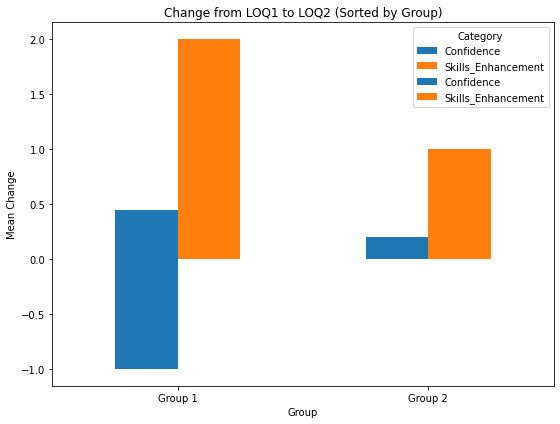

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

# Define the data
group_info = [1, 2, 2, 2, 1, 2, 2, 1, 1, 1, 2, 1, 1, 2, 1, 2, 1, 2, 2]

loq1_data = {
    "Confidence": [5, 4, 3, 3, 4, 4, 5, 4, 3, 4, 4, 3, 4, 5, 2, 5, 5, 5, 3],
    "Skills_Enhancement": [2, 3, 4, 2, 4, 4, 5, 4, 3, 4, 4, 4, 4, 4, 4, 5, 4, 5, 4]
}

loq2_data = {
    "Confidence": [4, 4, 4, 4, 4, 5, 4, 4, 5, 5, 5, 5, 4, 4, 2, 5, 5, 5, 3],
    "Skills_Enhancement": [4, 4, 4, 3, 4, 5, 4, 4, 5, 5, 5, 5, 4, 3, 4, 5, 5, 4, 3]
}

# Convert data to DataFrames
df_loq1 = pd.DataFrame(loq1_data)
df_loq2 = pd.DataFrame(loq2_data)

# Calculate the differences between LOQ1 and LOQ2 for each entry
df_diff = df_loq2 - df_loq1

# Set the figure size
plt.figure(figsize=(15, 6))

# Plot the overall changes
plt.subplot(1, 2, 1)
df_diff.plot(kind='bar', ax=plt.gca())
plt.title('Overall Change from LOQ1 to LOQ2')
plt.xlabel('Group')
plt.ylabel('Change')
plt.xticks(range(2), ['Group 1', 'Group 2'], rotation=0)
plt.legend(title='Category')

# Plot the changes sorted by group
#plt.subplot(1, 2)
df_diff_sorted = df_diff.groupby(group_info).mean()  # Calculate mean change per group
df_diff_sorted.plot(kind='bar', ax=plt.gca())
plt.title('Change from LOQ1 to LOQ2 (Sorted by Group)')
plt.xlabel('Group')
plt.ylabel('Mean Change')
plt.xticks(range(2), ['Group 1', 'Group 2'], rotation=0)
plt.legend(title='Category')

# Show plots
plt.tight_layout()
plt.show()


In [ ]:
f_diff_sorted = df_diff.groupby(group_info).mean()

# Print the values for change in confidence and skills for Group 1 and Group 2
print("Mean Change from LOQ1 to LOQ2 (Sorted by Group):")
print("Group 1 - Confidence Change:", df_diff_sorted.loc[1, 'Confidence'])
print("Group 1 - Skills Enhancement Change:", df_diff_sorted.loc[1, 'Skills_Enhancement'])
print("Group 2 - Confidence Change:", df_diff_sorted.loc[2, 'Confidence'])
print("Group 2 - Skills Enhancement Change:", df_diff_sorted.loc[2, 'Skills_Enhancement'])

In [16]:
import pandas as pd

# Define the data
group_info = [1, 2, 2, 2, 1, 2, 2, 1, 1, 1, 2, 1, 1, 2, 1, 2, 1, 2, 2]

loq1_data = {
    "Confidence": [5, 4, 3, 3, 4, 4, 5, 4, 3, 4, 4, 3, 4, 5, 2, 5, 5, 5, 3],
    "Skills_Enhancement": [2, 3, 4, 2, 4, 4, 5, 4, 3, 4, 4, 4, 4, 4, 4, 5, 4, 5, 4],
    "Group": group_info
}

loq2_data = {
    "Confidence": [4, 4, 4, 4, 4, 5, 4, 4, 5, 5, 5, 5, 4, 4, 2, 5, 5, 5, 3],
    "Skills_Enhancement": [4, 4, 4, 3, 4, 5, 4, 4, 5, 5, 5, 5, 4, 3, 4, 5, 5, 4, 3],
    "Group": group_info
}

# Convert data to DataFrames
df_loq1 = pd.DataFrame(loq1_data)
df_loq2 = pd.DataFrame(loq2_data)

# Calculate the average confidence and skills scores for LOQ1 and LOQ2 for Group 1
avg_loq1_g1 = df_loq1[df_loq1['Group'] == 1][['Confidence', 'Skills_Enhancement']].mean()
avg_loq2_g1 = df_loq2[df_loq2['Group'] == 1][['Confidence', 'Skills_Enhancement']].mean()

# Calculate the average confidence and skills scores for LOQ1 and LOQ2 for Group 2
avg_loq1_g2 = df_loq1[df_loq1['Group'] == 2][['Confidence', 'Skills_Enhancement']].mean()
avg_loq2_g2 = df_loq2[df_loq2['Group'] == 2][['Confidence', 'Skills_Enhancement']].mean()

# Print the average scores
print("Average Confidence and Skills Scores at LOQ1 and LOQ2 for Group 1:")
print("LOQ1:")
print("Confidence:", avg_loq1_g1['Confidence'])
print("Skills Enhancement:", avg_loq1_g1['Skills_Enhancement'])
print("LOQ2:")
print("Confidence:", avg_loq2_g1['Confidence'])
print("Skills Enhancement:", avg_loq2_g1['Skills_Enhancement'])

print("\nAverage Confidence and Skills Scores at LOQ1 and LOQ2 for Group 2:")
print("LOQ1:")
print("Confidence:", avg_loq1_g2['Confidence'])
print("Skills Enhancement:", avg_loq1_g2['Skills_Enhancement'])
print("LOQ2:")
print("Confidence:", avg_loq2_g2['Confidence'])
print("Skills Enhancement:", avg_loq2_g2['Skills_Enhancement'])


Average Confidence and Skills Scores at LOQ1 and LOQ2 for Group 1:
LOQ1:
Confidence: 3.7777777777777777
Skills Enhancement: 3.6666666666666665
LOQ2:
Confidence: 4.222222222222222
Skills Enhancement: 4.444444444444445

Average Confidence and Skills Scores at LOQ1 and LOQ2 for Group 2:
LOQ1:
Confidence: 4.1
Skills Enhancement: 4.0
LOQ2:
Confidence: 4.3
Skills Enhancement: 4.0


In [17]:
import pandas as pd

# Define the data
group_info = [1, 2, 2, 2, 1, 2, 2, 1, 1, 1, 2, 1, 1, 2, 1, 2, 1, 2, 2]

loq1_data = {
    "Confidence": [5, 4, 3, 3, 4, 4, 5, 4, 3, 4, 4, 3, 4, 5, 2, 5, 5, 5, 3],
    "Skills_Enhancement": [2, 3, 4, 2, 4, 4, 5, 4, 3, 4, 4, 4, 4, 4, 4, 5, 4, 5, 4],
    "Group": group_info
}

loq2_data = {
    "Confidence": [4, 4, 4, 4, 4, 5, 4, 4, 5, 5, 5, 5, 4, 4, 2, 5, 5, 5, 3],
    "Skills_Enhancement": [4, 4, 4, 3, 4, 5, 4, 4, 5, 5, 5, 5, 4, 3, 4, 5, 5, 4, 3],
    "Group": group_info
}

# Convert data to DataFrames
df_loq1 = pd.DataFrame(loq1_data)
df_loq2 = pd.DataFrame(loq2_data)

# Calculate the average and standard deviation confidence and skills scores for LOQ1 and LOQ2 for Group 1
avg_std_loq1_g1 = df_loq1[df_loq1['Group'] == 1][['Confidence', 'Skills_Enhancement']].agg(['mean', 'std'])
avg_std_loq2_g1 = df_loq2[df_loq2['Group'] == 1][['Confidence', 'Skills_Enhancement']].agg(['mean', 'std'])

# Calculate the average and standard deviation confidence and skills scores for LOQ1 and LOQ2 for Group 2
avg_std_loq1_g2 = df_loq1[df_loq1['Group'] == 2][['Confidence', 'Skills_Enhancement']].agg(['mean', 'std'])
avg_std_loq2_g2 = df_loq2[df_loq2['Group'] == 2][['Confidence', 'Skills_Enhancement']].agg(['mean', 'std'])

# Calculate combined mean and standard deviation for both groups together
combined_loq1 = df_loq1[['Confidence', 'Skills_Enhancement']].agg(['mean', 'std'])
combined_loq2 = df_loq2[['Confidence', 'Skills_Enhancement']].agg(['mean', 'std'])

# Print the results
print("Average and Standard Deviation of Confidence and Skills Scores at LOQ1 and LOQ2 for Group 1:")
print("LOQ1:")
print(avg_std_loq1_g1)
print("LOQ2:")
print(avg_std_loq2_g1)

print("\nAverage and Standard Deviation of Confidence and Skills Scores at LOQ1 and LOQ2 for Group 2:")
print("LOQ1:")
print(avg_std_loq1_g2)
print("LOQ2:")
print(avg_std_loq2_g2)

print("\nCombined Average and Standard Deviation of Confidence and Skills Scores at LOQ1 and LOQ2 for Both Groups:")
print("LOQ1:")
print(combined_loq1)
print("LOQ2:")
print(combined_loq2)


Average and Standard Deviation of Confidence and Skills Scores at LOQ1 and LOQ2 for Group 1:
LOQ1:
      Confidence  Skills_Enhancement
mean    3.777778            3.666667
std     0.971825            0.707107
LOQ2:
      Confidence  Skills_Enhancement
mean    4.222222            4.444444
std     0.971825            0.527046

Average and Standard Deviation of Confidence and Skills Scores at LOQ1 and LOQ2 for Group 2:
LOQ1:
      Confidence  Skills_Enhancement
mean    4.100000            4.000000
std     0.875595            0.942809
LOQ2:
      Confidence  Skills_Enhancement
mean    4.300000            4.000000
std     0.674949            0.816497

Combined Average and Standard Deviation of Confidence and Skills Scores at LOQ1 and LOQ2 for Both Groups:
LOQ1:
      Confidence  Skills_Enhancement
mean    3.947368            3.842105
std     0.911268            0.834210
LOQ2:
      Confidence  Skills_Enhancement
mean    4.263158            4.210526
std     0.805682            0.713283


In [ ]:
import pandas as pd

# Define the data for LOQ2
loq2_data = {
    "Group": [1, 2, 2, 2, 1, 2, 2, 1, 1, 1, 2, 1, 1, 2, 1, 2, 1, 2, 2],
    "Transition_Ease": [69, 75, 69, 90, 81, 98, 80, 95, 100, 90, 70, 72, 91, 80, 50, 100, 100, 94, 72],
    "Complementing_Learning": [39, 70, 70, 90, 100, 87, 100, 100, 100, 90, 60, 67, 98, 90, 38, 92, 75, 76, 11],
    "Learning_Enhancement": [95, 100, 69, 95, 65, 94, 74, 81, 100, 38, 55, 71, 84, 90, 63, 20, 60, 35, 82],
    "Learning_Order": [62, 65, 68, 30, 79, 95, 75, 100, 100, 50, 70, 58, 100, 83, 50, 18, 50, 100, 63],
    "Coherence": [39, 85, 64, 85, 79, 96, 23, 100, 100, 71, 55, 48, 80, 79, 96, 100, 75, 89, 78],
    "Continuity": [58, 90, 64, 90, 76, 97, 76, 100, 100, 50, 70, 40, 58, 83, 93, 100, 100, 100, 79]
}

# Convert data to DataFrame
df_loq2 = pd.DataFrame(loq2_data)

# Calculate the average ratings for each category
avg_ratings_loq2 = df_loq2.groupby('Group').mean()

# Print the average ratings for LOQ2
print("Average Ratings for LOQ2:")
print(avg_ratings_loq2)


In [ ]:
from scipy.stats import mannwhitneyu

# Separate data for Group 1 and Group 2
group1_data = df_loq2[df_loq2['Group'] == 1]
group2_data = df_loq2[df_loq2['Group'] == 2]

# Perform Mann-Whitney U test for each category
for column in df_loq2.columns[1:]:
    statistic, p_value = mannwhitneyu(group1_data[column], group2_data[column])
    print(f"Mann-Whitney U Test for {column}: Statistic = {statistic}, p-value = {p_value}")


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming df_loq2 is your DataFrame with data loaded

# Set the color palette
colors = ["red", "blue"]

# Find the overall y-axis limits
y_min = df_loq2.iloc[:, 1:].min().min()
y_max = df_loq2.iloc[:, 1:].max().max()

# List of questions for titles
questions = [
    "Ease of transitioning between experiences",
    "Complementary learning experiences",
    "Learnings from the 2nd experience",
    "Order of experiences effect",
    "Coherence between experiences",
    "Continuity in experiences"
]

# Adjusting figure size specifically for a 3x2 layout
plt.figure(figsize=(12, 15))  # Height is greater than width

for i, column in enumerate(df_loq2.columns[1:], 1):
    ax = plt.subplot(3, 2, i)  # Maintains the 3x2 layout
    sns.boxplot(x='Group', y=column, data=df_loq2, palette=colors)
    ax.set_ylim(y_min - 5, y_max + 5)
    ax.set_xlabel("Group", fontweight='bold', fontsize=16)
    ax.set_ylabel("Rating Scale (0 - 100)", fontweight='bold', fontsize=16)
    ax.set_title(questions[i-1], fontweight='bold', fontsize=16)
    
    # Adjust font size and weight of ticks
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontweight('bold')
        label.set_fontsize(16)

plt.tight_layout()
plt.savefig('Final_Updated_G1G2.png')
plt.show()


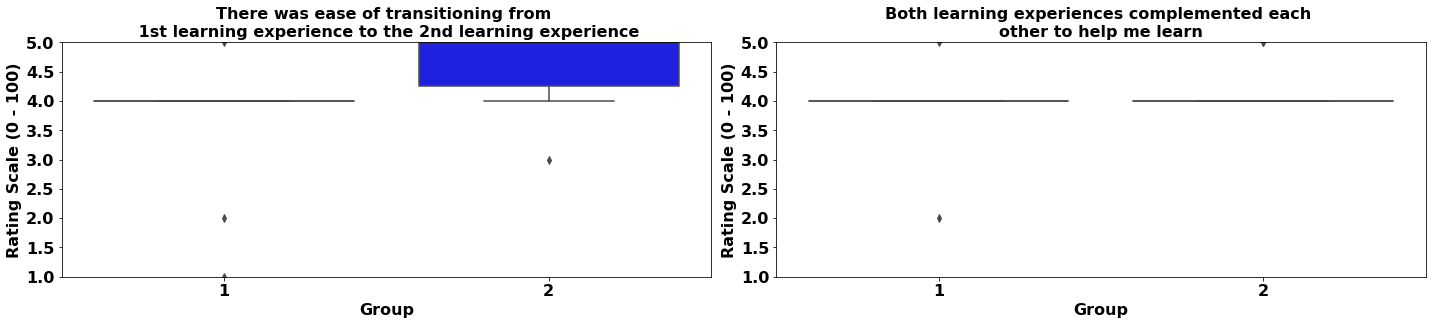

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming df_loq2 is your DataFrame with data loaded

# Set the color palette
colors = ["red", "blue"]

# Find the overall y-axis limits
y_min = df_loq2.iloc[:, 1:].values.min()
y_max = df_loq2.iloc[:, 1:].values.max()

# List of questions for titles
questions = [
    "There was ease of transitioning from \n 1st learning experience to the 2nd learning experience",
    "Both learning experiences complemented each \nother to help me learn",
    "I was able to learn more about the activity\n with the 2nd learning experience",
    "The order of the learning experienc\nhelped me learn better",
    "I found coherence between both \nlearning experiences",
    "There was continuity in the \nlearning experiences"
]

# Plot box plots for each category sorted by LOQ and Group
plt.figure(figsize=(20, 12))
for i, column in enumerate(df_loq2.columns[1:], 1):  # Skip 'Group' column
    plt.subplot(3, 2, i)
    sns.boxplot(x='Group', y=column, data=df_loq2, palette={1: colors[0], 2: colors[1]})
    plt.ylim(y_min, y_max)  # Set the y-axis limits
    plt.xlabel("Group",fontweight='bold', fontsize=16)
    plt.ylabel("Rating Scale (0 - 100)",fontweight='bold', fontsize=16)
    plt.title(questions[i-1],fontweight='bold', fontsize=16) 
    plt.xticks(fontweight='bold', fontsize=16)
    plt.yticks(fontweight='bold', fontsize=16)# Set the title using the corresponding question

plt.tight_layout()
file_name = 'Updated_G1G2.png'
plt.savefig(file_name)

plt.show()


In [ ]:
from scipy.stats import kruskal

oq2_data = {
    "Group": [1, 2, 2, 2, 1, 2, 2, 1, 1, 1, 2, 1, 1, 2, 1, 2, 1, 2, 2],
    "Transition_Ease": [69, 75, 69, 90, 81, 98, 80, 95, 100, 90, 70, 72, 91, 80, 50, 100, 100, 94, 72],
    "Complementing_Learning": [39, 70, 70, 90, 100, 87, 100, 100, 100, 90, 60, 67, 98, 90, 38, 92, 75, 76, 11],
    "Learning_Enhancement": [95, 100, 69, 95, 65, 94, 74, 81, 100, 38, 55, 71, 84, 90, 63, 20, 60, 35, 82],
    "Learning_Order": [62, 65, 68, 30, 79, 95, 75, 100, 100, 50, 70, 58, 100, 83, 50, 18, 50, 100, 63],
    "Coherence": [39, 85, 64, 85, 79, 96, 23, 100, 100, 71, 55, 48, 80, 79, 96, 100, 75, 89, 78],
    "Continuity": [58, 90, 64, 90, 76, 97, 76, 100, 100, 50, 70, 40, 58, 83, 93, 100, 100, 100, 79]
}

# Perform Kruskal-Wallis test for each variable
for key in oq2_data.keys():
    if key != "Group":
        h, p = kruskal(oq2_data[key], [oq2_data[key][i] for i in range(len(oq2_data[key])) if oq2_data["Group"][i] == 1], [oq2_data[key][i] for i in range(len(oq2_data[key])) if oq2_data["Group"][i] == 2])
        print(f"Kruskal-Wallis test for {key}:")
        print("H-statistic:", h)
        print("p-value:", p)
        if p < 0.05:
            print("The differences between groups are statistically significant.")
        else:
            print("There is no statistically significant difference between groups.")
        print()


In [ ]:
# Group Info array
group_info = [1, 2, 2, 2, 1, 2, 2, 1, 1, 1, 2, 1, 1, 2, 1, 2, 1, 2, 2]

# Initial Choices array
initial_choices = ['AR', 'VR', 'AR', 'VR', 'AR', 'VR', 'AR', 'AR', 'AR', 'VR', 'VR', 'AR', 'Both (Please explain)', 'AR', 'VR', 'AR', 'Both (Please explain)', 'AR', 'VR']

# Second Session Choices array
second_session_choices = ['AR', 'AR', 'AR', 'VR', 'AR', 'VR', 'AR', 'AR', 'AR', 'VR', 'VR', 'AR', 'VR', 'AR', 'VR', 'AR', 'AR', 'AR', 'VR']


In [ ]:
from scipy.stats import mannwhitneyu

# Perform Mann-Whitney U test between Group Info and Initial Choices
statistic_initial, p_value_initial = mannwhitneyu(group_info, initial_choices)

# Perform Mann-Whitney U test between Group Info and Second Session Choices
statistic_second, p_value_second = mannwhitneyu(group_info, second_session_choices)

# Print results
print("Mann-Whitney U test statistic between Group Info and Initial Choices:", statistic_initial)
print("p-value between Group Info and Initial Choices:", p_value_initial)

print("Mann-Whitney U test statistic between Group Info and Second Session Choices:", statistic_second)
print("p-value between Group Info and Second Session Choices:", p_value_second)


In [ ]:
import matplotlib.pyplot as plt

# Count the occurrences of each choice for Group 1 and Group 2
group1_initial_counts = {'AR': 0, 'VR': 0}
group1_second_counts = {'AR': 0, 'VR': 0}
group2_initial_counts = {'AR': 0, 'VR': 0}
group2_second_counts = {'AR': 0, 'VR': 0}

for group, initial_choice, second_choice in zip(group_info, initial_choices, second_session_choices):
    if group == 1:
        if initial_choice == 'Both (Please explain)':
            group1_initial_counts['AR'] += 1
            group1_initial_counts['VR'] += 1
        else:
            group1_initial_counts[initial_choice] += 1

        if second_choice == 'Both (Please explain)':
            group1_second_counts['AR'] += 1
            group1_second_counts['VR'] += 1
        else:
            group1_second_counts[second_choice] += 1
    elif group == 2:
        if initial_choice == 'Both (Please explain)':
            group2_initial_counts['AR'] += 1
            group2_initial_counts['VR'] += 1
        else:
            group2_initial_counts[initial_choice] += 1

        if second_choice == 'Both (Please explain)':
            group2_second_counts['AR'] += 1
            group2_second_counts['VR'] += 1
        else:
            group2_second_counts[second_choice] += 1

# Create bar plots
labels = ['AR', 'VR']
x = range(len(labels))
width = 0.3

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.bar(x, [group1_initial_counts['AR'], group1_initial_counts['VR']], width, label='Group 1', color=['blue', 'blue'])
plt.bar([i + width for i in x], [group2_initial_counts['AR'], group2_initial_counts['VR']], width, label='Group 2', color=['green', 'green'])
plt.xlabel('Choices')
plt.ylabel('Count')
plt.title('Initial Choices by Group(right after LOQ2)')
plt.xticks([i + width/2 for i in x], labels)
plt.ylim(0, 10)  # Set y-axis limit
plt.legend()

plt.subplot(1, 2, 2)
plt.bar(x, [group1_second_counts['AR'], group1_second_counts['VR']], width, label='Group 1', color=['blue', 'blue'])
plt.bar([i + width for i in x], [group2_second_counts['AR'], group2_second_counts['VR']], width, label='Group 2', color=['green', 'green'])
plt.xlabel('Choices')
plt.ylabel('Count')
plt.title('One Week Later Choices by Group(Pre Actual Task)')
plt.xticks([i + width/2 for i in x], labels)
plt.ylim(0, 10)  # Set y-axis limit
plt.legend()

plt.tight_layout()
plt.show()


In [1]:
# Group Info array
group_info = [1, 2, 2, 2, 1, 2, 2, 1, 1, 1, 2, 1, 1, 2, 1, 2, 1, 2, 2]

# Initial Choices array
initial_choices = ['AR', 'VR', 'AR', 'VR', 'AR', 'VR', 'AR', 'AR', 'AR', 'VR', 'VR', 'AR', 'Both (Please explain)', 'AR', 'VR', 'AR', 'Both (Please explain)', 'AR', 'VR']

# Second Session Choices array
second_session_choices = ['AR', 'AR', 'AR', 'VR', 'AR', 'VR', 'AR', 'AR', 'AR', 'VR', 'VR', 'AR', 'VR', 'AR', 'VR', 'AR', 'AR', 'AR', 'VR']


# Task arrays
Q1Task = [1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1]
Q2Task = [0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1]
Q3Task = [0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0]
Q4Task = [1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1]
Q5Task = [1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1]
Q6Task = [1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1]
TASKTOT = [4, 1, 4, 5, 2, 6, 2, 3, 5, 5, 1, 6, 5, 4, 6, 5, 3, 5, 4]


In [2]:
from scipy.stats import mannwhitneyu

# Calculate p-values using Mann-Whitney U test
p_values = []
for task_array in [Q1Task, Q2Task, Q3Task, Q4Task, Q5Task, Q6Task,TASKTOT]:
    _, p_value = mannwhitneyu(
        [task_array[i] for i in range(len(group_info)) if group_info[i] == 1],
        [task_array[i] for i in range(len(group_info)) if group_info[i] == 2]
    )
    p_values.append(p_value)

print("P-values for each task:")
for i, p_value in enumerate(p_values):
    print(f"Task {i+1}: p-value = {p_value}")


P-values for each task:
Task 1: p-value = 0.3256892232381963
Task 2: p-value = 0.45966650264766906
Task 3: p-value = 0.14713305215248146
Task 4: p-value = 0.04256584242366708
Task 5: p-value = 0.37421376156778147
Task 6: p-value = 0.45966650264766906
Task 7: p-value = 0.225964600755021


In [3]:
tasks = [Q1Task, Q2Task, Q3Task, Q4Task, Q5Task, Q6Task, TASKTOT]
task_names = ['Q1Task', 'Q2Task', 'Q3Task', 'Q4Task', 'Q5Task', 'Q6Task', 'TASKTOT']

for task, task_name in zip(tasks, task_names):
    stat, p = mannwhitneyu(task, group_info)
    print(f"Mann-Whitney U test statistic between {task_name} and Group Info: {stat}")
    print(f"p-value between {task_name} and Group Info: {p}")

Mann-Whitney U test statistic between Q1Task and Group Info: 72.0
p-value between Q1Task and Group Info: 7.947215759720779e-05
Mann-Whitney U test statistic between Q2Task and Group Info: 58.5
p-value between Q2Task and Group Info: 3.0973898479702533e-05
Mann-Whitney U test statistic between Q3Task and Group Info: 36.0
p-value between Q3Task and Group Info: 3.2280048341595643e-06
Mann-Whitney U test statistic between Q4Task and Group Info: 58.5
p-value between Q4Task and Group Info: 3.0973898479702533e-05
Mann-Whitney U test statistic between Q5Task and Group Info: 63.0
p-value between Q5Task and Group Info: 4.3800444658417936e-05
Mann-Whitney U test statistic between Q6Task and Group Info: 58.5
p-value between Q6Task and Group Info: 3.0973898479702533e-05
Mann-Whitney U test statistic between TASKTOT and Group Info: 39.0
p-value between TASKTOT and Group Info: 1.0798921747121608e-05


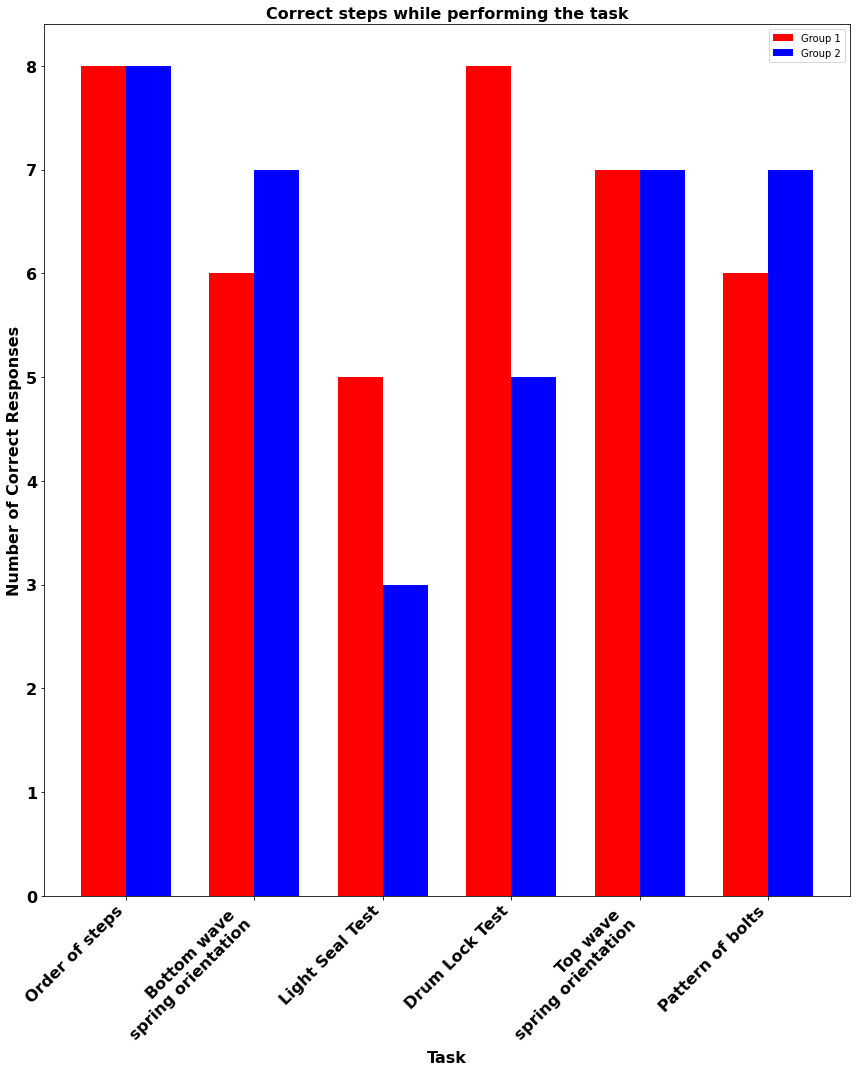

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# Task names
task_names = ['Q1Task', 'Q2Task', 'Q3Task', 'Q4Task', 'Q5Task', 'Q6Task']

# Correct counts for Group 1 and Group 2 (excluding TASKTOT)
correct_counts_group1 = [sum(Q1Task[i] for i in range(len(group_info)) if group_info[i] == 1),
                         sum(Q2Task[i] for i in range(len(group_info)) if group_info[i] == 1),
                         sum(Q3Task[i] for i in range(len(group_info)) if group_info[i] == 1),
                         sum(Q4Task[i] for i in range(len(group_info)) if group_info[i] == 1),
                         sum(Q5Task[i] for i in range(len(group_info)) if group_info[i] == 1),
                         sum(Q6Task[i] for i in range(len(group_info)) if group_info[i] == 1)]

correct_counts_group2 = [sum(Q1Task[i] for i in range(len(group_info)) if group_info[i] == 2),
                         sum(Q2Task[i] for i in range(len(group_info)) if group_info[i] == 2),
                         sum(Q3Task[i] for i in range(len(group_info)) if group_info[i] == 2),
                         sum(Q4Task[i] for i in range(len(group_info)) if group_info[i] == 2),
                         sum(Q5Task[i] for i in range(len(group_info)) if group_info[i] == 2),
                         sum(Q6Task[i] for i in range(len(group_info)) if group_info[i] == 2)]

# Plot
fig, ax = plt.subplots(figsize=(12, 15))
bar_width = 0.35
index = np.arange(len(task_names))

bar1 = ax.bar(index, correct_counts_group1, bar_width, color='red', label='Group 1')
bar2 = ax.bar(index + bar_width, correct_counts_group2, bar_width, color='blue', label='Group 2')

ax.set_xlabel('Task',fontweight = 'bold',fontsize=16)
ax.set_ylabel('Number of Correct Responses',fontweight = 'bold',fontsize=16)
ax.set_title('Correct steps while performing the task',fontweight = 'bold',fontsize=16)
ax.set_xticks(index + bar_width / 2)
ax.set_xticklabels(['Order of steps', 'Bottom wave \n spring orientation', 'Light Seal Test', 'Drum Lock Test', 'Top wave \n spring orientation', 'Pattern of bolts'], rotation=45, ha='right')  # Hard-coded tick labels as '0', '1', '2', '3', '4', '5'
ax.legend()
file_name = 'Updated_ER_1.png'
plt.xticks(fontweight='bold', fontsize=16)
plt.yticks(fontweight='bold', fontsize=16)
plt.savefig(file_name)

plt.tight_layout()
plt.show()


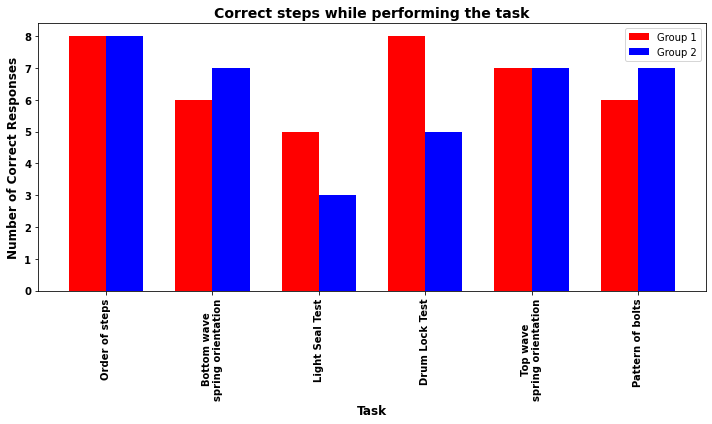

In [5]:
import matplotlib.pyplot as plt
import numpy as np

# Task names
task_names = ['Q1Task', 'Q2Task', 'Q3Task', 'Q4Task', 'Q5Task', 'Q6Task']

# Correct counts for Group 1 and Group 2 (excluding TASKTOT)
correct_counts_group1 = [sum(Q1Task[i] for i in range(len(group_info)) if group_info[i] == 1),
                         sum(Q2Task[i] for i in range(len(group_info)) if group_info[i] == 1),
                         sum(Q3Task[i] for i in range(len(group_info)) if group_info[i] == 1),
                         sum(Q4Task[i] for i in range(len(group_info)) if group_info[i] == 1),
                         sum(Q5Task[i] for i in range(len(group_info)) if group_info[i] == 1),
                         sum(Q6Task[i] for i in range(len(group_info)) if group_info[i] == 1)]

correct_counts_group2 = [sum(Q1Task[i] for i in range(len(group_info)) if group_info[i] == 2),
                         sum(Q2Task[i] for i in range(len(group_info)) if group_info[i] == 2),
                         sum(Q3Task[i] for i in range(len(group_info)) if group_info[i] == 2),
                         sum(Q4Task[i] for i in range(len(group_info)) if group_info[i] == 2),
                         sum(Q5Task[i] for i in range(len(group_info)) if group_info[i] == 2),
                         sum(Q6Task[i] for i in range(len(group_info)) if group_info[i] == 2)]

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
bar_width = 0.35
index = np.arange(len(task_names))

bar1 = ax.bar(index, correct_counts_group1, bar_width, color='red', label='Group 1')
bar2 = ax.bar(index + bar_width, correct_counts_group2, bar_width, color='blue', label='Group 2')

ax.set_xlabel('Task', fontweight='bold', fontsize=12)
ax.set_ylabel('Number of Correct Responses', fontweight='bold', fontsize=12)
ax.set_title('Correct steps while performing the task', fontweight='bold', fontsize=14)
ax.set_xticks(index + bar_width / 2)
ax.set_xticklabels(['Order of steps', 'Bottom wave\nspring orientation', 'Light Seal Test', 'Drum Lock Test', 'Top wave\nspring orientation', 'Pattern of bolts'], rotation=90, ha='center') 
ax.legend()

plt.xticks(fontweight='bold', fontsize=10)
plt.yticks(fontweight='bold', fontsize=10)
plt.tight_layout()
plt.savefig('Updated_ER_1_compact.png')
plt.show()


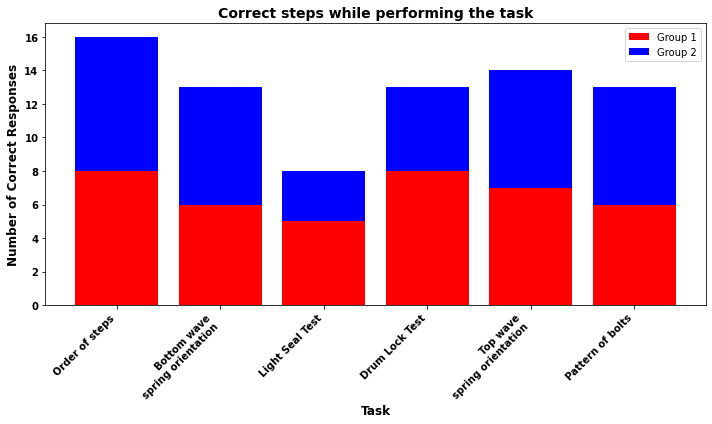

In [6]:
import matplotlib.pyplot as plt
import numpy as np

# Task names
task_names = ['Order of steps', 'Bottom wave\nspring orientation', 'Light Seal Test', 'Drum Lock Test', 'Top wave\nspring orientation', 'Pattern of bolts']

# Correct counts for Group 1 and Group 2 (excluding TASKTOT)
correct_counts_group1 = [sum(Q1Task[i] for i in range(len(group_info)) if group_info[i] == 1),
                         sum(Q2Task[i] for i in range(len(group_info)) if group_info[i] == 1),
                         sum(Q3Task[i] for i in range(len(group_info)) if group_info[i] == 1),
                         sum(Q4Task[i] for i in range(len(group_info)) if group_info[i] == 1),
                         sum(Q5Task[i] for i in range(len(group_info)) if group_info[i] == 1),
                         sum(Q6Task[i] for i in range(len(group_info)) if group_info[i] == 1)]

correct_counts_group2 = [sum(Q1Task[i] for i in range(len(group_info)) if group_info[i] == 2),
                         sum(Q2Task[i] for i in range(len(group_info)) if group_info[i] == 2),
                         sum(Q3Task[i] for i in range(len(group_info)) if group_info[i] == 2),
                         sum(Q4Task[i] for i in range(len(group_info)) if group_info[i] == 2),
                         sum(Q5Task[i] for i in range(len(group_info)) if group_info[i] == 2),
                         sum(Q6Task[i] for i in range(len(group_info)) if group_info[i] == 2)]

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
index = np.arange(len(task_names))

bar1 = ax.bar(index, correct_counts_group1, color='red', label='Group 1')
bar2 = ax.bar(index, correct_counts_group2, bottom=correct_counts_group1, color='blue', label='Group 2')

ax.set_xlabel('Task', fontweight='bold', fontsize=12)
ax.set_ylabel('Number of Correct Responses', fontweight='bold', fontsize=12)
ax.set_title('Correct steps while performing the task', fontweight='bold', fontsize=14)
ax.set_xticks(index)
ax.set_xticklabels(task_names, rotation=45, ha='right')
ax.legend()

plt.xticks(fontweight='bold', fontsize=10)
plt.yticks(fontweight='bold', fontsize=10)
plt.tight_layout()
plt.savefig('Updated_ER_1_stacked.png')
plt.show()


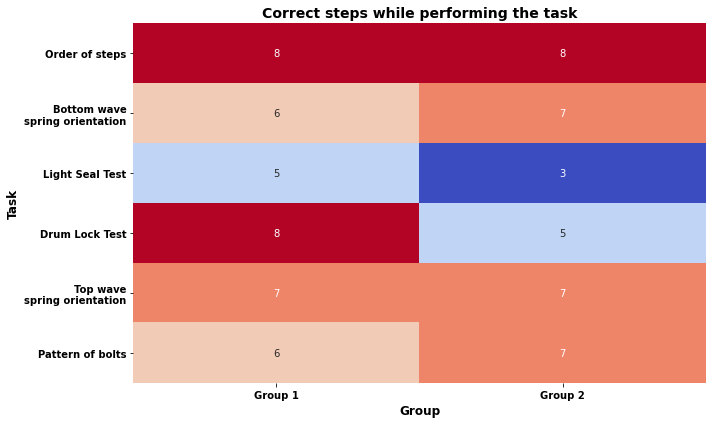

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Task names
task_names = ['Order of steps', 'Bottom wave\nspring orientation', 'Light Seal Test', 'Drum Lock Test', 'Top wave\nspring orientation', 'Pattern of bolts']

# Correct counts for Group 1 and Group 2 (excluding TASKTOT)
correct_counts = [
    [sum(Q1Task[i] for i in range(len(group_info)) if group_info[i] == 1),
     sum(Q1Task[i] for i in range(len(group_info)) if group_info[i] == 2)],
    [sum(Q2Task[i] for i in range(len(group_info)) if group_info[i] == 1),
     sum(Q2Task[i] for i in range(len(group_info)) if group_info[i] == 2)],
    [sum(Q3Task[i] for i in range(len(group_info)) if group_info[i] == 1),
     sum(Q3Task[i] for i in range(len(group_info)) if group_info[i] == 2)],
    [sum(Q4Task[i] for i in range(len(group_info)) if group_info[i] == 1),
     sum(Q4Task[i] for i in range(len(group_info)) if group_info[i] == 2)],
    [sum(Q5Task[i] for i in range(len(group_info)) if group_info[i] == 1),
     sum(Q5Task[i] for i in range(len(group_info)) if group_info[i] == 2)],
    [sum(Q6Task[i] for i in range(len(group_info)) if group_info[i] == 1),
     sum(Q6Task[i] for i in range(len(group_info)) if group_info[i] == 2)]
]

# Create heatmap
fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(correct_counts, annot=True, fmt='d', cmap='coolwarm', xticklabels=['Group 1', 'Group 2'], yticklabels=task_names, cbar=False, ax=ax)

ax.set_xlabel('Group', fontweight='bold', fontsize=12)
ax.set_ylabel('Task', fontweight='bold', fontsize=12)
ax.set_title('Correct steps while performing the task', fontweight='bold', fontsize=14)

plt.xticks(fontweight='bold', fontsize=10)
plt.yticks(fontweight='bold', fontsize=10)
plt.tight_layout()
plt.savefig('Updated_ER_1_heatmap.png')
plt.show()


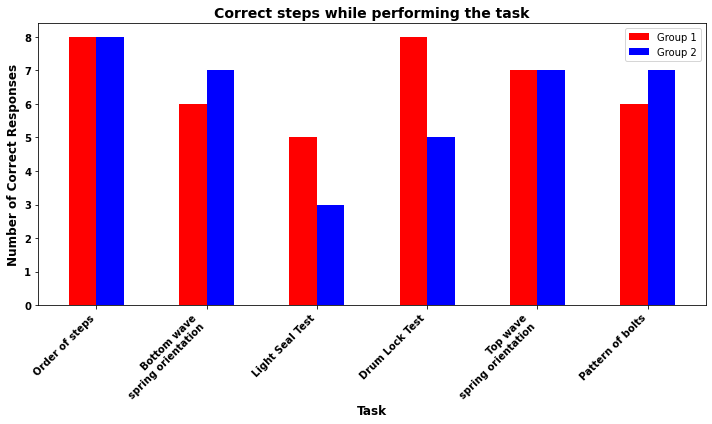

In [8]:
import matplotlib.pyplot as plt
import numpy as np

# Task names
task_names = ['Order of steps', 'Bottom wave\nspring orientation', 'Light Seal Test', 'Drum Lock Test', 'Top wave\nspring orientation', 'Pattern of bolts']

# Correct counts for Group 1 and Group 2 (excluding TASKTOT)
correct_counts_group1 = [sum(Q1Task[i] for i in range(len(group_info)) if group_info[i] == 1),
                         sum(Q2Task[i] for i in range(len(group_info)) if group_info[i] == 1),
                         sum(Q3Task[i] for i in range(len(group_info)) if group_info[i] == 1),
                         sum(Q4Task[i] for i in range(len(group_info)) if group_info[i] == 1),
                         sum(Q5Task[i] for i in range(len(group_info)) if group_info[i] == 1),
                         sum(Q6Task[i] for i in range(len(group_info)) if group_info[i] == 1)]

correct_counts_group2 = [sum(Q1Task[i] for i in range(len(group_info)) if group_info[i] == 2),
                         sum(Q2Task[i] for i in range(len(group_info)) if group_info[i] == 2),
                         sum(Q3Task[i] for i in range(len(group_info)) if group_info[i] == 2),
                         sum(Q4Task[i] for i in range(len(group_info)) if group_info[i] == 2),
                         sum(Q5Task[i] for i in range(len(group_info)) if group_info[i] == 2),
                         sum(Q6Task[i] for i in range(len(group_info)) if group_info[i] == 2)]

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
bar_width = 0.25
index = np.arange(len(task_names))

bar1 = ax.bar(index, correct_counts_group1, bar_width, color='red', label='Group 1')
bar2 = ax.bar(index + bar_width, correct_counts_group2, bar_width, color='blue', label='Group 2')

ax.set_xlabel('Task', fontweight='bold', fontsize=12)
ax.set_ylabel('Number of Correct Responses', fontweight='bold', fontsize=12)
ax.set_title('Correct steps while performing the task', fontweight='bold', fontsize=14)
ax.set_xticks(index + bar_width / 2)
ax.set_xticklabels(task_names, rotation=45, ha='right')
ax.legend()

plt.xticks(fontweight='bold', fontsize=10)
plt.yticks(fontweight='bold', fontsize=10)
plt.tight_layout()
plt.savefig('Updated_ER_1_compact_bars.png')
plt.show()


In [ ]:
import matplotlib.pyplot as plt

# Calculate the sum of correct responses for tasks Q1 to Q6
sum_correct_responses_group1 = sum(correct_counts_group1)
sum_correct_responses_group2 = sum(correct_counts_group2)

# Calculate the sum of TASKTOT values for each group
sum_TASKTOT_group1 = sum(TASKTOT[i] for i in range(len(group_info)) if group_info[i] == 1)
sum_TASKTOT_group2 = sum(TASKTOT[i] for i in range(len(group_info)) if group_info[i] == 2)

# Plot
fig, ax = plt.subplots(figsize=(10, 6))

# Plot sum of correct responses for Q1 to Q6
ax.bar(['Q1-Q6'], [sum_correct_responses_group1], label='Group 1', color='skyblue', width=0.4, align='center')
ax.bar(['Q1-Q6'], [sum_correct_responses_group2], label='Group 2', color='salmon', width=0.4, align='edge')

# Plot sum of TASKTOT
ax.bar(['TASKTOT'], [sum_TASKTOT_group1], label='Group 1', color='lightgreen', width=0.4, align='center', alpha=0.6)
ax.bar(['TASKTOT'], [sum_TASKTOT_group2], label='Group 2', color='lightcoral', width=0.4, align='edge', alpha=0.6)

ax.set_ylabel('Sum of Correct Responses / TASKTOT')
ax.set_title('Sum of Correct Responses vs TASKTOT by Group')
ax.legend()

plt.tight_layout()
plt.show()


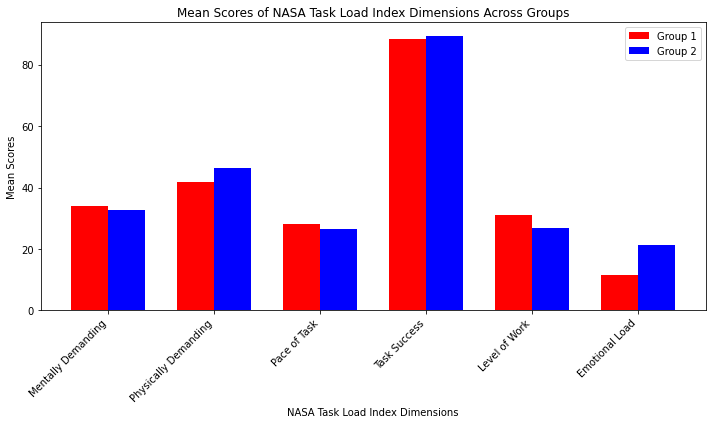

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# NASA Task Load Index scores
mentally_demanding = [29, 20, 50, 10, 29, 0, 60, 51, 19, 29, 30, 39, 15, 9, 71, 10, 25, 67, 71]
physically_demanding = [25, 40, 61, 20, 29, 14, 81, 83, 38, 51, 45, 51, 32, 16, 1, 10, 65, 91, 85]
pace_of_task = [40, 36, 40, 15, 28, 0, 58, 20, 29, 51, 50, 37, 15, 11, 22, 10, 10, 4, 40]
task_success = [84, 71, 100, 95, 75, 94, 92, 100, 91, 100, 95, 90, 89, 91, 65, 92, 100, 88, 75]
level_of_work = [27, 31, 30, 10, 55, 4, 10, 20, 19, 51, 40, 47, 23, 14, 17, 10, 20, 34, 86]
emotional_load = [14, 24, 30, 0, 32, 0, 10, 0, 0, 0, 0, 0, 14, 85, 44, 10, 0, 14, 40]

# Group assignments
group_info = [1, 2, 2, 2, 1, 2, 2, 1, 1, 1, 2, 1, 1, 2, 1, 2, 1, 2, 2]

# Calculate mean scores for each dimension for each group
group1_means = [
    np.mean([mentally_demanding[i] for i in range(len(group_info)) if group_info[i] == 1]),
    np.mean([physically_demanding[i] for i in range(len(group_info)) if group_info[i] == 1]),
    np.mean([pace_of_task[i] for i in range(len(group_info)) if group_info[i] == 1]),
    np.mean([task_success[i] for i in range(len(group_info)) if group_info[i] == 1]),
    np.mean([level_of_work[i] for i in range(len(group_info)) if group_info[i] == 1]),
    np.mean([emotional_load[i] for i in range(len(group_info)) if group_info[i] == 1])
]

group2_means = [
    np.mean([mentally_demanding[i] for i in range(len(group_info)) if group_info[i] == 2]),
    np.mean([physically_demanding[i] for i in range(len(group_info)) if group_info[i] == 2]),
    np.mean([pace_of_task[i] for i in range(len(group_info)) if group_info[i] == 2]),
    np.mean([task_success[i] for i in range(len(group_info)) if group_info[i] == 2]),
    np.mean([level_of_work[i] for i in range(len(group_info)) if group_info[i] == 2]),
    np.mean([emotional_load[i] for i in range(len(group_info)) if group_info[i] == 2])
]

# Task Load Index dimensions
dimensions = ['Mentally Demanding', 'Physically Demanding', 'Pace of Task', 'Task Success', 'Level of Work', 'Emotional Load']

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
bar_width = 0.35
index = np.arange(len(dimensions))

bar1 = ax.bar(index, group1_means, bar_width, color='red', label='Group 1')
bar2 = ax.bar(index + bar_width, group2_means, bar_width, color='blue', label='Group 2')

ax.set_xlabel('NASA Task Load Index Dimensions')
ax.set_ylabel('Mean Scores')
ax.set_title('Mean Scores of NASA Task Load Index Dimensions Across Groups')
ax.set_xticks(index + bar_width / 2)
ax.set_xticklabels(dimensions, rotation=45, ha='right')
ax.legend()

plt.tight_layout()
plt.show()


In [ ]:
from scipy.stats import mannwhitneyu

# Calculate average TLX scores for each participant
tlx_scores_group1 = []
tlx_scores_group2 = []

for i in range(len(group_info)):
    tlx_score = (mentally_demanding[i] + physically_demanding[i] + pace_of_task[i] + task_success[i] + level_of_work[i] + emotional_load[i]) / 6
    if group_info[i] == 1:
        tlx_scores_group1.append(tlx_score)
    else:
        tlx_scores_group2.append(tlx_score)

# Run Mann-Whitney U test
statistic, p_value = mannwhitneyu(tlx_scores_group1, tlx_scores_group2)

print("Mann-Whitney U test statistic:", statistic)
print("p-value:", p_value)


In [ ]:
from scipy.stats import mannwhitneyu

# TLX scores for each dimension
tlx_scores_dimensions = [
    mentally_demanding,
    physically_demanding,
    pace_of_task,
    task_success,
    level_of_work,
    emotional_load
]

# Run Mann-Whitney U test for each dimension
for i, dimension_scores in enumerate(tlx_scores_dimensions):
    group1_scores = [dimension_scores[j] for j in range(len(group_info)) if group_info[j] == 1]
    group2_scores = [dimension_scores[j] for j in range(len(group_info)) if group_info[j] == 2]
    statistic, p_value = mannwhitneyu(group1_scores, group2_scores)
    print(f"Mann-Whitney U test statistic for {dimensions[i]}:", statistic)
    print(f"p-value for {dimensions[i]}:", p_value)


In [ ]:
# Plotting piano plots for each category
plt.figure(figsize=(14, 10))

# Iterate through each category
for i, column in enumerate(df_loq1.columns[1:-1], start=1):
    plt.subplot(3, 4, i)
    sns.violinplot(x="Group", y=column, data=pd.concat([df_loq1[[column, 'Group']], df_loq2[[column, 'Group']]]), 
                   hue="Group", palette={1: "red", 2: "blue"}, split=True, inner="quartile", cut=0, bw='scott')
    plt.title(column)

plt.tight_layout()
plt.show()


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Data
data = {
    "Group": [1, 2, 2, 2, 1, 2, 2, 1, 1, 1, 2, 1, 1, 2, 1, 2, 1, 2, 2],
    "LOQ0": [2, 0, 2, 4, 2, 2, 1, 0, 0, 2, 2, 0, 0, 2, 0, 2, 3, 2, 0],
    "LOQ1": [5, 3, 1, 6, 2, 4, 3, 3, 2, 6, 4, 2, 3, 4, 4, 4, 3, 6, 5],
    "LOQ2": [4, 5, 3, 6, 3, 5, 4, 3, 2, 5, 5, 4, 4, 4, 5, 4, 3, 6, 3],
    "LOQ3": [4, 5, 2, 5, 2, 6, 4, 4, 2, 5, 5, 3, 4, 3, 5, 5, 3, 5, 3],
}

# Create dataframe
df = pd.DataFrame(data)

# Calculate means for each stage for the legend
mean_group1_per_stage = df[df['Group'] == 1].mean()
mean_group2_per_stage = df[df['Group'] == 2].mean()

# Melting the data for easier visualization
df_melt = df.melt(id_vars=["Group"], var_name="Stage", value_name="Correct Answers")

# Create subplots with manual height spacing
fig = plt.figure(figsize=(14, 16))
gs = fig.add_gridspec(4, 2, height_ratios=[1, 0.2, 1.5, 0.5], width_ratios=[1, 1])

# Top-left: Group 1
ax1 = fig.add_subplot(gs[0, 0])
sns.boxplot(x="Stage", y="Correct Answers", data=df_melt[df_melt["Group"] == 1], ax=ax1, palette="Blues")
ax1.set_title("Group 1 Distribution Across Stages")
ax1.set_ylabel("Correct Answers (Out of 6)")

# Adding the mean values as a legend inside the plot for Group 1
mean_text_group1 = '\n'.join([f'{stage}: {mean:.2f}' for stage, mean in mean_group1_per_stage[1:].items()])
ax1.text(1.02, 0.8, f"Means:\n{mean_text_group1}", transform=ax1.transAxes, fontsize=10, verticalalignment='top', bbox=dict(facecolor='white', alpha=0.5))

# Top-right: Group 2
ax2 = fig.add_subplot(gs[0, 1])
sns.boxplot(x="Stage", y="Correct Answers", data=df_melt[df_melt["Group"] == 2], ax=ax2, palette="Greens")
ax2.set_title("Group 2 Distribution Across Stages")
ax2.set_ylabel("Correct Answers (Out of 6)")

# Adding the mean values as a legend inside the plot for Group 2
mean_text_group2 = '\n'.join([f'{stage}: {mean:.2f}' for stage, mean in mean_group2_per_stage[1:].items()])
ax2.text(1.02, 0.8, f"Means:\n{mean_text_group2}", transform=ax2.transAxes, fontsize=10, verticalalignment='top', bbox=dict(facecolor='white', alpha=0.5))

# Middle row for the table
ax_table = fig.add_subplot(gs[1, :])
ax_table.axis('off')  # We don't want any axis here, just the table

# Table data (only p-values)
p_values = [
    ["LOQ0 → LOQ1", "3.26 ×10−5"],
    ["LOQ0 → LOQ2", "1.25 ×10−6"],
    ["LOQ0 → LOQ3", "5.05 ×10−6"],
    ["LOQ1 → LOQ2", "0.3225"],
    ["LOQ1 → LOQ3", "0.5306"],
    ["LOQ2 → LOQ3", "0.7859"]
]

# Adding the table in the middle row
table = ax_table.table(cellText=p_values, colLabels=["Comparison", "p-value"], loc='center', cellLoc='center')
table.auto_set_font_size(False)
table.set_fontsize(10)

# Bottom center: Combined
ax3 = fig.add_subplot(gs[2, :])  # This takes the whole row
sns.boxplot(x="Stage", y="Correct Answers", data=df_melt, ax=ax3, palette="Purples")
ax3.set_title("Combined Distribution Across Stages (Group 1 and 2 Combined)")
ax3.set_ylabel("Correct Answers (Out of 6)")
ax3.set_xlabel("Number of Correct Answers at Different Stages of Exposures")

plt.tight_layout()
plt.show()
fig.savefig("poster1_plot.jpeg", format='jpeg', dpi=300)



KeyboardInterrupt: 

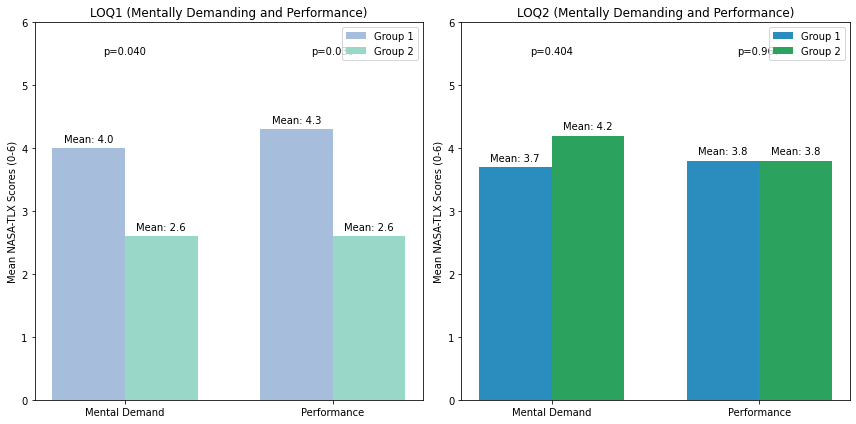

In [2]:
import matplotlib.pyplot as plt
import numpy as np

# Data from LOQ1 and LOQ2 based on provided values
metrics = ['Mental Demand', 'Performance']

# LOQ1 (Group 1, Group 2, p-values)
group1_means_loq1 = [4.0, 4.3]
group2_means_loq1 = [2.6, 2.6]
p_values_loq1 = [0.040, 0.030]

# LOQ2 (Group 1, Group 2, p-values)
group1_means_loq2 = [3.7, 3.8]
group2_means_loq2 = [4.2, 3.8]
p_values_loq2 = [0.404, 0.967]

# Set up figure with colors matching the palette from the boxplot
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

# X positions for the bars
x = np.arange(len(metrics))

# Bar width
width = 0.35

# Plot for LOQ1 with colors matching the palette for Group 1 and Group 2
bar1_loq1 = ax[0].bar(x - width/2, group1_means_loq1, width, label='Group 1', color='#a6bddb')  # Light blue
bar2_loq1 = ax[0].bar(x + width/2, group2_means_loq1, width, label='Group 2', color='#99d8c9')  # Light green

# Plot for LOQ2 with colors matching the palette for Group 1 and Group 2
bar1_loq2 = ax[1].bar(x - width/2, group1_means_loq2, width, label='Group 1', color='#2b8cbe')  # Darker blue
bar2_loq2 = ax[1].bar(x + width/2, group2_means_loq2, width, label='Group 2', color='#2ca25f')  # Darker green

# Customize LOQ1 plot
ax[0].set_ylabel('Mean NASA-TLX Scores (0-6)')
ax[0].set_title('LOQ1 (Mentally Demanding and Performance)')
ax[0].set_xticks(x)
ax[0].set_xticklabels(metrics)
ax[0].set_ylim(0, 6)

# Add p-values and means for LOQ1
for i in range(len(metrics)):
    ax[0].text(i - width/2, group1_means_loq1[i] + 0.1, f'Mean: {group1_means_loq1[i]:.1f}', ha='center', fontsize=10)
    ax[0].text(i + width/2, group2_means_loq1[i] + 0.1, f'Mean: {group2_means_loq1[i]:.1f}', ha='center', fontsize=10)
    ax[0].text(i, 5.5, f'p={p_values_loq1[i]:.3f}', ha='center', fontsize=10)

# Customize LOQ2 plot
ax[1].set_ylabel('Mean NASA-TLX Scores (0-6)')
ax[1].set_title('LOQ2 (Mentally Demanding and Performance)')
ax[1].set_xticks(x)
ax[1].set_xticklabels(metrics)
ax[1].set_ylim(0, 6)

# Add p-values and means for LOQ2
for i in range(len(metrics)):
    ax[1].text(i - width/2, group1_means_loq2[i] + 0.1, f'Mean: {group1_means_loq2[i]:.1f}', ha='center', fontsize=10)
    ax[1].text(i + width/2, group2_means_loq2[i] + 0.1, f'Mean: {group2_means_loq2[i]:.1f}', ha='center', fontsize=10)
    ax[1].text(i, 5.5, f'p={p_values_loq2[i]:.3f}', ha='center', fontsize=10)

# Add legends
ax[0].legend()
ax[1].legend()

plt.tight_layout()
plt.show()


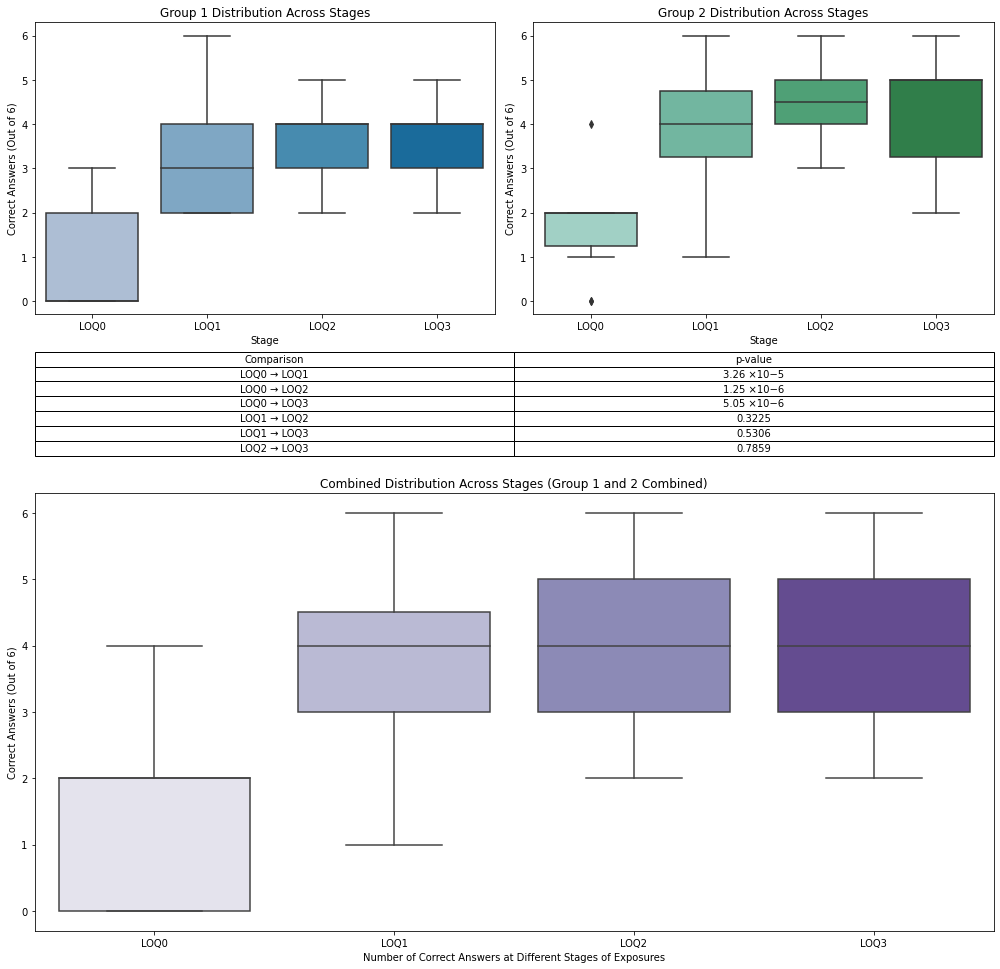

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# Custom color palette for Group 1 and Group 2 across all LOQ stages
palette_group1 = ["#a6bddb", "#74a9cf", "#3690c0", "#0570b0"]  # Shades of blue for Group 1
palette_group2 = ["#99d8c9", "#66c2a4", "#41ae76", "#238b45"]  # Shades of green for Group 2

# Data for boxplots and bar plots
data = {
    "Group": [1, 2, 2, 2, 1, 2, 2, 1, 1, 1, 2, 1, 1, 2, 1, 2, 1, 2, 2],
    "LOQ0": [2, 0, 2, 4, 2, 2, 1, 0, 0, 2, 2, 0, 0, 2, 0, 2, 3, 2, 0],
    "LOQ1": [5, 3, 1, 6, 2, 4, 3, 3, 2, 6, 4, 2, 3, 4, 4, 4, 3, 6, 5],
    "LOQ2": [4, 5, 3, 6, 3, 5, 4, 3, 2, 5, 5, 4, 4, 4, 5, 4, 3, 6, 3],
    "LOQ3": [4, 5, 2, 5, 2, 6, 4, 4, 2, 5, 5, 3, 4, 3, 5, 5, 3, 5, 3],
}

# Create dataframe
df = pd.DataFrame(data)

# Melting the data for easier visualization
df_melt = df.melt(id_vars=["Group"], var_name="Stage", value_name="Correct Answers")

# Create subplots with custom color palette
fig = plt.figure(figsize=(14, 16))
gs = fig.add_gridspec(4, 2, height_ratios=[1, 0.2, 1.5, 0.5], width_ratios=[1, 1])

# Top-left: Group 1 Boxplot (LOQ stages)
ax1 = fig.add_subplot(gs[0, 0])
sns.boxplot(x="Stage", y="Correct Answers", data=df_melt[df_melt["Group"] == 1], ax=ax1, 
            palette=palette_group1)
ax1.set_title("Group 1 Distribution Across Stages")
ax1.set_ylabel("Correct Answers (Out of 6)")

# Top-right: Group 2 Boxplot (LOQ stages)
ax2 = fig.add_subplot(gs[0, 1])
sns.boxplot(x="Stage", y="Correct Answers", data=df_melt[df_melt["Group"] == 2], ax=ax2, 
            palette=palette_group2)
ax2.set_title("Group 2 Distribution Across Stages")
ax2.set_ylabel("Correct Answers (Out of 6)")

# Middle row for the table (p-values)
ax_table = fig.add_subplot(gs[1, :])
ax_table.axis('off')
p_values = [
    ["LOQ0 → LOQ1", "3.26 ×10−5"],
    ["LOQ0 → LOQ2", "1.25 ×10−6"],
    ["LOQ0 → LOQ3", "5.05 ×10−6"],
    ["LOQ1 → LOQ2", "0.3225"],
    ["LOQ1 → LOQ3", "0.5306"],
    ["LOQ2 → LOQ3", "0.7859"]
]
table = ax_table.table(cellText=p_values, colLabels=["Comparison", "p-value"], loc='center', cellLoc='center')
table.auto_set_font_size(False)
table.set_fontsize(10)

# Bottom row: Combined Boxplot (Group 1 & 2) with consistent colors
ax3 = fig.add_subplot(gs[2, :])
sns.boxplot(x="Stage", y="Correct Answers", data=df_melt, ax=ax3, 
            palette="Purples")
ax3.set_title("Combined Distribution Across Stages (Group 1 and 2 Combined)")
ax3.set_ylabel("Correct Answers (Out of 6)")
ax3.set_xlabel("Number of Correct Answers at Different Stages of Exposures")


plt.tight_layout()
plt.savefig("poster1_plot.jpeg", format='jpeg', dpi=300)
plt.show()

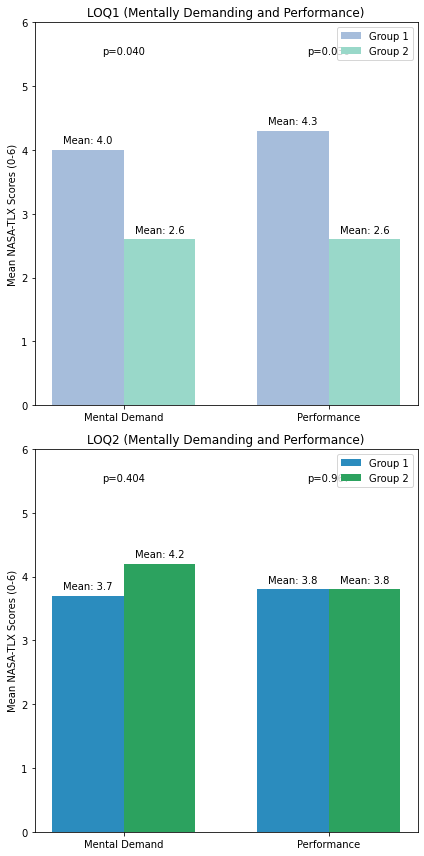

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# Data from LOQ1 and LOQ2 based on provided values
metrics = ['Mental Demand', 'Performance']

# LOQ1 (Group 1, Group 2, p-values)
group1_means_loq1 = [4.0, 4.3]
group2_means_loq1 = [2.6, 2.6]
p_values_loq1 = [0.040, 0.030]

# LOQ2 (Group 1, Group 2, p-values)
group1_means_loq2 = [3.7, 3.8]
group2_means_loq2 = [4.2, 3.8]
p_values_loq2 = [0.404, 0.967]

# Set up figure in portrait orientation
fig, ax = plt.subplots(2, 1, figsize=(6, 12))  # 2 rows, 1 column

# X positions for the bars
x = np.arange(len(metrics))

# Bar width
width = 0.35

# Plot for LOQ1 with colors matching the palette for Group 1 and Group 2
bar1_loq1 = ax[0].bar(x - width/2, group1_means_loq1, width, label='Group 1', color='#a6bddb')  # Light blue
bar2_loq1 = ax[0].bar(x + width/2, group2_means_loq1, width, label='Group 2', color='#99d8c9')  # Light green

# Plot for LOQ2 with colors matching the palette for Group 1 and Group 2
bar1_loq2 = ax[1].bar(x - width/2, group1_means_loq2, width, label='Group 1', color='#2b8cbe')  # Darker blue
bar2_loq2 = ax[1].bar(x + width/2, group2_means_loq2, width, label='Group 2', color='#2ca25f')  # Darker green

# Customize LOQ1 plot
ax[0].set_ylabel('Mean NASA-TLX Scores (0-6)')
ax[0].set_title('LOQ1 (Mentally Demanding and Performance)')
ax[0].set_xticks(x)
ax[0].set_xticklabels(metrics)
ax[0].set_ylim(0, 6)

# Add p-values and means for LOQ1
for i in range(len(metrics)):
    ax[0].text(i - width/2, group1_means_loq1[i] + 0.1, f'Mean: {group1_means_loq1[i]:.1f}', ha='center', fontsize=10)
    ax[0].text(i + width/2, group2_means_loq1[i] + 0.1, f'Mean: {group2_means_loq1[i]:.1f}', ha='center', fontsize=10)
    ax[0].text(i, 5.5, f'p={p_values_loq1[i]:.3f}', ha='center', fontsize=10)

# Customize LOQ2 plot
ax[1].set_ylabel('Mean NASA-TLX Scores (0-6)')
ax[1].set_title('LOQ2 (Mentally Demanding and Performance)')
ax[1].set_xticks(x)
ax[1].set_xticklabels(metrics)
ax[1].set_ylim(0, 6)

# Add p-values and means for LOQ2
for i in range(len(metrics)):
    ax[1].text(i - width/2, group1_means_loq2[i] + 0.1, f'Mean: {group1_means_loq2[i]:.1f}', ha='center', fontsize=10)
    ax[1].text(i + width/2, group2_means_loq2[i] + 0.1, f'Mean: {group2_means_loq2[i]:.1f}', ha='center', fontsize=10)
    ax[1].text(i, 5.5, f'p={p_values_loq2[i]:.3f}', ha='center', fontsize=10)

# Add legends
ax[0].legend()
ax[1].legend()

# Adjust layout for portrait mode
plt.tight_layout()
plt.savefig("portrait_1.jpeg", format='jpeg', dpi=300)
plt.show()


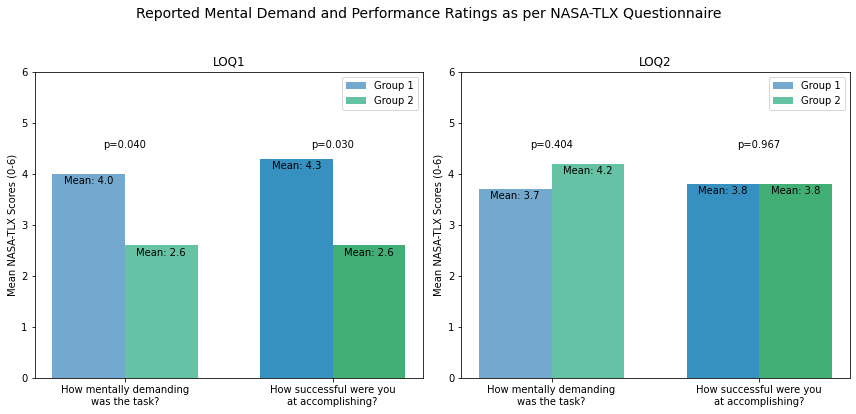

In [30]:
import matplotlib.pyplot as plt
import numpy as np

# Data for TLX metrics (Mental Demand and Performance)
metrics_tlx = ['Mental Demand', 'Performance']

# LOQ1 (Group 1, Group 2, p-values)
group1_means_loq1_tlx = [4.0, 4.3]
group2_means_loq1_tlx = [2.6, 2.6]
p_values_loq1_tlx = [0.040, 0.030]

# LOQ2 (Group 1, Group 2, p-values)
group1_means_loq2_tlx = [3.7, 3.8]
group2_means_loq2_tlx = [4.2, 3.8]
p_values_loq2_tlx = [0.404, 0.967]

# Palette colors for LOQ1 and LOQ2
palette_group1 = ["#74a9cf", "#3690c0"]  # Light blue shades for Group 1
palette_group2 = ["#66c2a4", "#41ae76"]  # Light green shades for Group 2

# Adjusted questions for the x-axis based on NASA-TLX standard questions in two lines
metrics_tlx_labels = ['How mentally demanding\nwas the task?', 'How successful were you\nat accomplishing?']

# Set up figure for TLX bar plots
fig_tlx, ax_tlx = plt.subplots(1, 2, figsize=(12, 6))

# General title for both plots
fig_tlx.suptitle('Reported Mental Demand and Performance Ratings as per NASA-TLX Questionnaire', fontsize=14)

# X positions for the bars
x_tlx = np.arange(len(metrics_tlx))

# Bar width
width = 0.35

# Plot for LOQ1 (TLX)
bar1_loq1_tlx = ax_tlx[0].bar(x_tlx - width/2, group1_means_loq1_tlx, width, label='Group 1', color=palette_group1)
bar2_loq1_tlx = ax_tlx[0].bar(x_tlx + width/2, group2_means_loq1_tlx, width, label='Group 2', color=palette_group2)

# Add p-values and means for LOQ1 (TLX)
for i in range(len(metrics_tlx)):
    ax_tlx[0].text(i - width/2, group1_means_loq1_tlx[i] - 0.2, f'Mean: {group1_means_loq1_tlx[i]:.1f}', ha='center', fontsize=10)
    ax_tlx[0].text(i + width/2, group2_means_loq1_tlx[i] - 0.2, f'Mean: {group2_means_loq1_tlx[i]:.1f}', ha='center', fontsize=10)
    ax_tlx[0].text(i, 4.5, f'p={p_values_loq1_tlx[i]:.3f}', ha='center', fontsize=10)

# Plot for LOQ2 (TLX)
bar1_loq2_tlx = ax_tlx[1].bar(x_tlx - width/2, group1_means_loq2_tlx, width, label='Group 1', color=palette_group1)
bar2_loq2_tlx = ax_tlx[1].bar(x_tlx + width/2, group2_means_loq2_tlx, width, label='Group 2', color=palette_group2)

# Add p-values and means for LOQ2 (TLX)
for i in range(len(metrics_tlx)):
    ax_tlx[1].text(i - width/2, group1_means_loq2_tlx[i] - 0.2, f'Mean: {group1_means_loq2_tlx[i]:.1f}', ha='center', fontsize=10)
    ax_tlx[1].text(i + width/2, group2_means_loq2_tlx[i] - 0.2, f'Mean: {group2_means_loq2_tlx[i]:.1f}', ha='center', fontsize=10)
    ax_tlx[1].text(i, 4.5, f'p={p_values_loq2_tlx[i]:.3f}', ha='center', fontsize=10)

# Customize LOQ1 (TLX) plot
ax_tlx[0].set_ylabel('Mean NASA-TLX Scores (0-6)')
ax_tlx[0].set_title('LOQ1', fontsize=12)
ax_tlx[0].set_xticks(x_tlx)
ax_tlx[0].set_xticklabels(metrics_tlx_labels, rotation=0, ha="center")
ax_tlx[0].set_ylim(0, 6)

# Customize LOQ2 (TLX) plot
ax_tlx[1].set_ylabel('Mean NASA-TLX Scores (0-6)')
ax_tlx[1].set_title('LOQ2', fontsize=12)
ax_tlx[1].set_xticks(x_tlx)
ax_tlx[1].set_xticklabels(metrics_tlx_labels, rotation=0, ha="center")
ax_tlx[1].set_ylim(0, 6)

# Add legends
ax_tlx[0].legend()
ax_tlx[1].legend()

plt.tight_layout(rect=[0, 0.03, 1, 0.95])  # Adjusting layout to accommodate the general title
plt.savefig("poster2_plot.jpeg", format='jpeg', dpi=300)
plt.show()




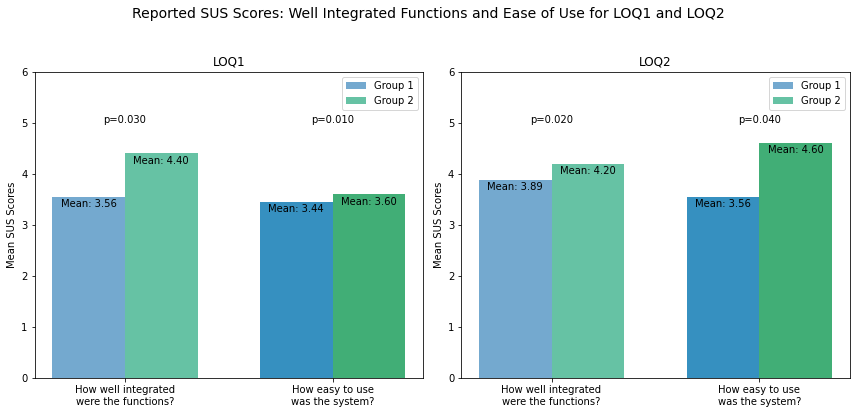

In [35]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Define the raw data for LOQ1 and LOQ2
group_info = [1, 2, 2, 2, 1, 2, 2, 1, 1, 1, 2, 1, 1, 2, 1, 2, 1, 2, 2]

loq1_data = {
    "Group": group_info,
    "Easy_to_Use": [2, 1, 4, 4, 4, 4, 4, 4, 5, 2, 4, 5, 4, 5, 3, 5, 2, 3, 2],
    "Well_Integrated_Functions": [2, 4, 5, 4, 4, 5, 5, 4, 4, 4, 5, 4, 5, 4, 1, 4, 4, 4, 4],
}

loq2_data = {
    "Group": group_info,
    "Easy_to_Use": [4, 4, 4, 5, 4, 5, 5, 5, 2, 4, 5, 4, 4, 5, 1, 5, 4, 3, 5],
    "Well_Integrated_Functions": [4, 4, 4, 4, 4, 5, 4, 5, 4, 4, 4, 4, 4, 5, 2, 4, 4, 4, 4],
}

# Convert the data to DataFrames
df_loq1 = pd.DataFrame(loq1_data)
df_loq2 = pd.DataFrame(loq2_data)

# Calculate mean values for both LOQ1 and LOQ2
mean_loq1 = df_loq1.groupby("Group").mean()
mean_loq2 = df_loq2.groupby("Group").mean()

# Data for SUS metrics (Well Integrated Functions and Easy to Use)
metrics_sus = ['Well Integrated Functions', 'Easy to Use']

# LOQ1 (Group 1, Group 2, p-values)
group1_means_sus_loq1 = [mean_loq1['Well_Integrated_Functions'][1], mean_loq1['Easy_to_Use'][1]]
group2_means_sus_loq1 = [mean_loq1['Well_Integrated_Functions'][2], mean_loq1['Easy_to_Use'][2]]

# LOQ2 (Group 1, Group 2, p-values)
group1_means_sus_loq2 = [mean_loq2['Well_Integrated_Functions'][1], mean_loq2['Easy_to_Use'][1]]
group2_means_sus_loq2 = [mean_loq2['Well_Integrated_Functions'][2], mean_loq2['Easy_to_Use'][2]]

# p-values for the metrics
p_values_sus_loq1 = [0.03, 0.01]
p_values_sus_loq2 = [0.02, 0.04]

# Palette colors for SUS metrics similar to previous plot style
palette_group1 = ["#74a9cf", "#3690c0"]  # Light blue shades for Group 1
palette_group2 = ["#66c2a4", "#41ae76"]  # Light green shades for Group 2

# Adjusted questions for the x-axis based on SUS questions in two lines
metrics_sus_labels = ['How well integrated\nwere the functions?', 'How easy to use\nwas the system?']

# Set up figure for SUS bar plots
fig_sus, ax_sus = plt.subplots(1, 2, figsize=(12, 6))

# General title for the plots
fig_sus.suptitle('Reported SUS Scores: Well Integrated Functions and Ease of Use for LOQ1 and LOQ2', fontsize=14)

# X positions for the bars
x_sus = np.arange(len(metrics_sus))

# Bar width
width = 0.35

# Plot for LOQ1 SUS metrics
bar1_sus_loq1 = ax_sus[0].bar(x_sus - width/2, group1_means_sus_loq1, width, label='Group 1', color=palette_group1)
bar2_sus_loq1 = ax_sus[0].bar(x_sus + width/2, group2_means_sus_loq1, width, label='Group 2', color=palette_group2)

# Add p-values and means for LOQ1 SUS metrics
for i in range(len(metrics_sus)):
    ax_sus[0].text(i - width/2, group1_means_sus_loq1[i] - 0.2, f'Mean: {group1_means_sus_loq1[i]:.2f}', ha='center', fontsize=10)
    ax_sus[0].text(i + width/2, group2_means_sus_loq1[i] - 0.2, f'Mean: {group2_means_sus_loq1[i]:.2f}', ha='center', fontsize=10)
    ax_sus[0].text(i, 5.0, f'p={p_values_sus_loq1[i]:.3f}', ha='center', fontsize=10)

# Customize LOQ1 SUS plot
ax_sus[0].set_ylabel('Mean SUS Scores')
ax_sus[0].set_title('LOQ1', fontsize=12)
ax_sus[0].set_xticks(x_sus)
ax_sus[0].set_xticklabels(metrics_sus_labels, rotation=0, ha="center")
ax_sus[0].set_ylim(0, 6)

# Plot for LOQ2 SUS metrics
bar1_sus_loq2 = ax_sus[1].bar(x_sus - width/2, group1_means_sus_loq2, width, label='Group 1', color=palette_group1)
bar2_sus_loq2 = ax_sus[1].bar(x_sus + width/2, group2_means_sus_loq2, width, label='Group 2', color=palette_group2)

# Add p-values and means for LOQ2 SUS metrics
for i in range(len(metrics_sus)):
    ax_sus[1].text(i - width/2, group1_means_sus_loq2[i] - 0.2, f'Mean: {group1_means_sus_loq2[i]:.2f}', ha='center', fontsize=10)
    ax_sus[1].text(i + width/2, group2_means_sus_loq2[i] - 0.2, f'Mean: {group2_means_sus_loq2[i]:.2f}', ha='center', fontsize=10)
    ax_sus[1].text(i, 5.0, f'p={p_values_sus_loq2[i]:.3f}', ha='center', fontsize=10)

# Customize LOQ2 SUS plot
ax_sus[1].set_ylabel('Mean SUS Scores')
ax_sus[1].set_title('LOQ2', fontsize=12)
ax_sus[1].set_xticks(x_sus)
ax_sus[1].set_xticklabels(metrics_sus_labels, rotation=0, ha="center")
ax_sus[1].set_ylim(0, 6)

# Add legend
ax_sus[0].legend()
ax_sus[1].legend()

plt.tight_layout(rect=[0, 0.03, 1, 0.95])  # Adjusting layout to accommodate the general title
plt.savefig("poster3_plot.jpeg", format='jpeg', dpi=300)
plt.show()


In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Define the data for LOQ2
loq2_data = {
    "Group": [1, 2, 2, 2, 1, 2, 2, 1, 1, 1, 2, 1, 1, 2, 1, 2, 1, 2, 2],
    "Transition_Ease": [69, 75, 69, 90, 81, 98, 80, 95, 100, 90, 70, 72, 91, 80, 50, 100, 100, 94, 72],
    "Complementing_Learning": [39, 70, 70, 90, 100, 87, 100, 100, 100, 90, 60, 67, 98, 90, 38, 92, 75, 76, 11],
    "Learning_Enhancement": [95, 100, 69, 95, 65, 94, 74, 81, 100, 38, 55, 71, 84, 90, 63, 20, 60, 35, 82],
    "Learning_Order": [62, 65, 68, 30, 79, 95, 75, 100, 100, 50, 70, 58, 100, 83, 50, 18, 50, 100, 63],
    "Coherence": [39, 85, 64, 85, 79, 96, 23, 100, 100, 71, 55, 48, 80, 79, 96, 100, 75, 89, 78],
    "Continuity": [58, 90, 64, 90, 76, 97, 76, 100, 100, 50, 70, 40, 58, 83, 93, 100, 100, 100, 79]
}

# Convert data to DataFrame
df_loq2 = pd.DataFrame(loq2_data)

# Melting the data for easier visualization
df_loq2_melted = df_loq2.melt(id_vars=["Group"], var_name="Category", value_name="Rating")

# Palette colors to match previous plots
palette_group1 = "#74a9cf"  # Light blue for Group 1
palette_group2 = "#66c2a4"  # Light green for Group 2

# Set up the figure with 6 subplots in a 3x2 layout
fig, axes = plt.subplots(2, 3, figsize=(16, ))

# Adjust figure layout
plt.subplots_adjust(hspace=0.3, wspace=0.3)
fig.suptitle('Differences in Responses Based on Order of Exposure to AR and VR Regarding Technology Transition', fontsize=16)

# Categories to plot
categories = [
    "Transition_Ease",
    "Complementing_Learning",
    "Learning_Enhancement",
    "Learning_Order",
    "Coherence",
    "Continuity"
]

titles = [
    "Ease of transitioning between experiences",
    "Complementary learning experiences",
    "Improved learning from the 2nd experience",
    "Positive learning experiences based on the order",
    "Coherence between experiences",
    "Continuity in experiences"
]

# Create box plots for each category
for i, ax in enumerate(axes.flatten()):
    sns.boxplot(x="Group", y="Rating", data=df_loq2_melted[df_loq2_melted['Category'] == categories[i]], ax=ax, palette=[palette_group1, palette_group2])
    ax.set_title(titles[i])
    ax.set_ylabel('Rating Scale (0 - 100)')
    ax.set_xlabel('Group')

# Display the plot
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig("poster4_plot.jpeg", format='jpeg', dpi=300)
plt.show()


TypeError: from_bounds() missing 1 required positional argument: 'height'

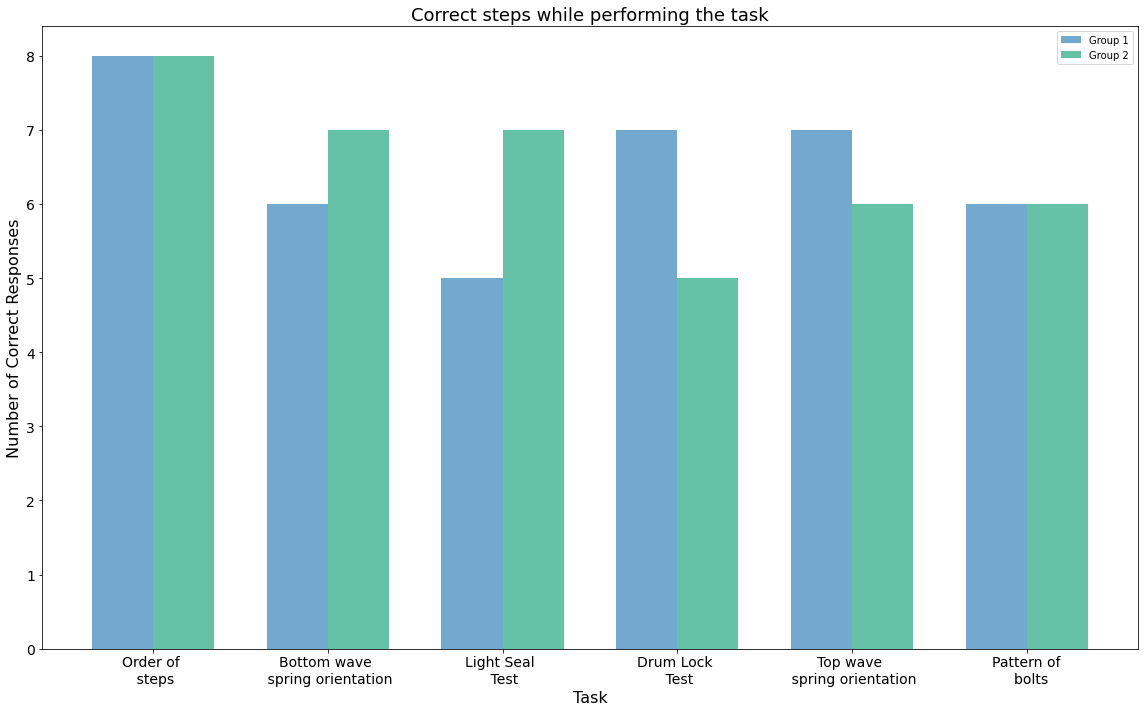

In [9]:
import matplotlib.pyplot as plt
import numpy as np

# Task names with line breaks for longer labels
task_names = ['Order of \n steps', 'Bottom wave \n spring orientation', 'Light Seal \n Test', 'Drum Lock \n Test', 
              'Top wave \n spring orientation', 'Pattern of\n  bolts']

# Correct counts for Group 1 and Group 2
correct_counts_group1 = [8, 6, 5, 7, 7, 6]
correct_counts_group2 = [8, 7, 7, 5, 6, 6]

# Set up figure with a wider and more spaced layout
fig, ax = plt.subplots(figsize=(16, 10))  # Adjusting figure size for consistency
bar_width = 0.35
index = np.arange(len(task_names))

# New color palette for consistency with previous LOQ plots
palette_group1 = "#74a9cf"  # Light blue for Group 1
palette_group2 = "#66c2a4"  # Light green for Group 2

# Plot bars with the matching colors from LOQ2
bar1 = ax.bar(index, correct_counts_group1, bar_width, color=palette_group1, label='Group 1')
bar2 = ax.bar(index + bar_width, correct_counts_group2, bar_width, color=palette_group2, label='Group 2')

# Labels, ticks, and formatting
ax.set_xlabel('Task', fontsize=16)
ax.set_ylabel('Number of Correct Responses', fontsize=16)
ax.set_title('Correct steps while performing the task', fontsize=18)
ax.set_xticks(index + bar_width / 2)

# Adjust the x-axis tick labels to appear split into two lines where necessary
ax.set_xticklabels(task_names, rotation=0, ha='center')

ax.legend()

# Formatting the axis ticks
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

# Adjust the layout and save the figure
plt.tight_layout()
plt.savefig("poster5_plot.jpeg", format='jpeg', dpi=300)
plt.show()


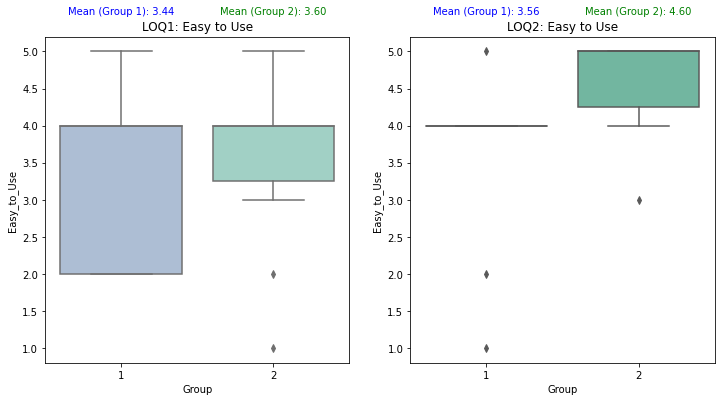

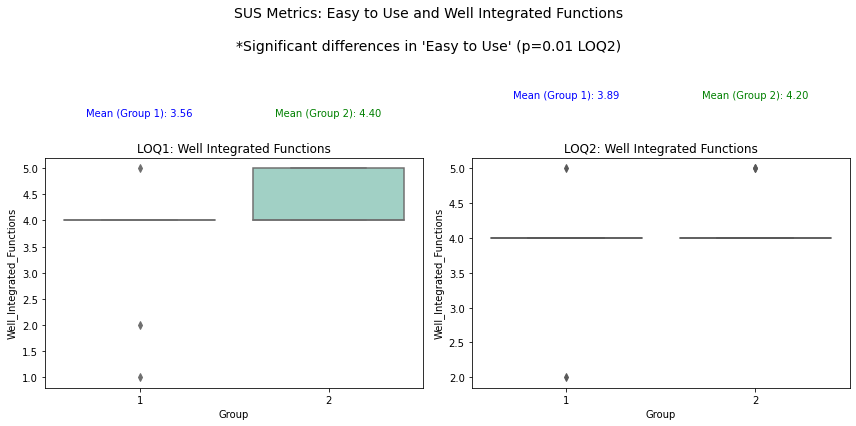

In [23]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Define the raw data for LOQ1 and LOQ2
group_info = [1, 2, 2, 2, 1, 2, 2, 1, 1, 1, 2, 1, 1, 2, 1, 2, 1, 2, 2]

loq1_data = {
    "Group": group_info,
    "Easy_to_Use": [2, 1, 4, 4, 4, 4, 4, 4, 5, 2, 4, 5, 4, 5, 3, 5, 2, 3, 2],
    "Well_Integrated_Functions": [2, 4, 5, 4, 4, 5, 5, 4, 4, 4, 5, 4, 5, 4, 1, 4, 4, 4, 4],
}

loq2_data = {
    "Group": group_info,
    "Easy_to_Use": [4, 4, 4, 5, 4, 5, 5, 5, 2, 4, 5, 4, 4, 5, 1, 5, 4, 3, 5],
    "Well_Integrated_Functions": [4, 4, 4, 4, 4, 5, 4, 5, 4, 4, 4, 4, 4, 5, 2, 4, 4, 4, 4],
}

# Convert data to DataFrames
df_loq1 = pd.DataFrame(loq1_data)
df_loq2 = pd.DataFrame(loq2_data)

# Palette colors for consistency with previous plots
palette_group1 = ["#a6bddb", "#74a9cf"]  # Light blue shades for Group 1
palette_group2 = ["#99d8c9", "#66c2a4"]  # Light green shades for Group 2

# Plot for "Easy to Use" (LOQ1 and LOQ2)
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

# LOQ1: Easy to Use
sns.boxplot(x="Group", y="Easy_to_Use", data=df_loq1, palette=[palette_group1[0], palette_group2[0]], ax=ax[0])
ax[0].set_title("LOQ1: Easy to Use")

# LOQ2: Easy to Use
sns.boxplot(x="Group", y="Easy_to_Use", data=df_loq2, palette=[palette_group1[1], palette_group2[1]], ax=ax[1])
ax[1].set_title("LOQ2: Easy to Use")

# Calculate and annotate the means for each group
mean_loq1_group1 = df_loq1[df_loq1['Group'] == 1]['Easy_to_Use'].mean()
mean_loq1_group2 = df_loq1[df_loq1['Group'] == 2]['Easy_to_Use'].mean()
mean_loq2_group1 = df_loq2[df_loq2['Group'] == 1]['Easy_to_Use'].mean()
mean_loq2_group2 = df_loq2[df_loq2['Group'] == 2]['Easy_to_Use'].mean()

ax[0].text(0, 5.5, f'Mean (Group 1): {mean_loq1_group1:.2f}', horizontalalignment='center', color='blue', fontsize=10)
ax[0].text(1, 5.5, f'Mean (Group 2): {mean_loq1_group2:.2f}', horizontalalignment='center', color='green', fontsize=10)
ax[1].text(0, 5.5, f'Mean (Group 1): {mean_loq2_group1:.2f}', horizontalalignment='center', color='blue', fontsize=10)
ax[1].text(1, 5.5, f'Mean (Group 2): {mean_loq2_group2:.2f}', horizontalalignment='center', color='green', fontsize=10)

# Plot for "Well Integrated Functions" (LOQ1 and LOQ2)
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

# LOQ1: Well Integrated Functions
sns.boxplot(x="Group", y="Well_Integrated_Functions", data=df_loq1, palette=[palette_group1[0], palette_group2[0]], ax=ax[0])
ax[0].set_title("LOQ1: Well Integrated Functions")

# LOQ2: Well Integrated Functions
sns.boxplot(x="Group", y="Well_Integrated_Functions", data=df_loq2, palette=[palette_group1[1], palette_group2[1]], ax=ax[1])
ax[1].set_title("LOQ2: Well Integrated Functions")

# Calculate and annotate the means for each group
mean_loq1_group1_wif = df_loq1[df_loq1['Group'] == 1]['Well_Integrated_Functions'].mean()
mean_loq1_group2_wif = df_loq1[df_loq1['Group'] == 2]['Well_Integrated_Functions'].mean()
mean_loq2_group1_wif = df_loq2[df_loq2['Group'] == 1]['Well_Integrated_Functions'].mean()
mean_loq2_group2_wif = df_loq2[df_loq2['Group'] == 2]['Well_Integrated_Functions'].mean()

ax[0].text(0, 6, f'Mean (Group 1): {mean_loq1_group1_wif:.2f}', horizontalalignment='center', color='blue', fontsize=10)
ax[0].text(1, 6, f'Mean (Group 2): {mean_loq1_group2_wif:.2f}', horizontalalignment='center', color='green', fontsize=10)
ax[1].text(0, 6, f'Mean (Group 1): {mean_loq2_group1_wif:.2f}', horizontalalignment='center', color='blue', fontsize=10)
ax[1].text(1, 6, f'Mean (Group 2): {mean_loq2_group2_wif:.2f}', horizontalalignment='center', color='green', fontsize=10)

# Final legend
fig.suptitle("SUS Metrics: Easy to Use and Well Integrated Functions\n\n*Significant differences in 'Easy to Use' (p=0.01 LOQ2)", fontsize=14)

plt.tight_layout()
plt.show()


In [ ]:
print(len(correct_counts_group1))
print(len(correct_counts_group2))
print(len(index))

In [ ]:
pip install pingouin